# Aprendizaje Profundo: Aplicación de LLMs.

## Tabla de Contenidos <a name="toc"></a>

1. [Introducción](#introduccion)
2. [Descarga y Verificación del DataFrame](#dataframe)
3. [Modelo de Clasificación BiLSTM con Capa de Atención](#modelosbilstm)
    - 3.1. [Preprocesamiento de los datos](#modelosbilstm)
    - 3.2. [Modelo BiLSTM con Attention](#modelosbilstm)
    - 3.3. [Conclusiones sobre el modelo](#modelosbilstm)
4. [Modelos SLM (Small Language Models) Autoregresivos](#modeloslm)
    - 4.1 [Clasificación con TinyLlama sobre el dataset IMDB](#modeloslm)
    - 4.2 [Clasificación con GPT-Neo sobre el dataset IMDB](#modeloslm)
5. [Modelo BERT](#modeloscnnlstm)
6. [Conclusiones](#conclusiones)

## 1. Introducción <a name="introduccion"></a>

En lo que sigue, analizaremos el siguiente dataset para aplicar NPL:

* ***Título***: IMDB Dataset of 50K Movie Reviews
* ***Autor***: Lakshmi N Pathi (Kaggle)
* ***Fuente***: [dataset de reviews de IMDB](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/code)

#### Descripción general

Este dataset contiene 50.000 reseñas de películas obtenidas de IMDB útiles para procesamiento de lenguaje natural (NLP) o análisis de texto. Cada reseña está clasificada binaria de sentimientos como positiva o negativa, por lo que se utiliza ampliamente para tareas de análisis de sentimientos (sentiment analysis). Uno de los primeros antecedentes en el análisis de este `dataset` fue realizado en el trabajo *"Learning Word Vectors for Sentiment Analysis"* por Andrew Maas, Raymond Daly, Peter Pham, Dan Huang, Andrew Ng, y Christopher Potts [[1]](https://preview.aclanthology.org/ingestion-script-update/P11-1.pdf).

| Columna     | Tipo       | Descripción                             |
| ----------- | ---------- | --------------------------------------- |
| `review`    | texto      | Texto completo de la reseña de película |
| `sentiment` | categórica | “positive” o “negative”                 |

#### Características

- Tamaño equilibrado: 25.000 positivas y 25.000 negativas.
- Ideal para probar modelos de NLP (procesamiento de lenguaje natural) como:
    - Bag of Words, TF-IDF.
    - Word embeddings (Word2Vec, GloVe).
- Redes neuronales (LSTM, Transformers).
- Dataset limpio, sin etiquetas neutras ni puntuaciones numéricas.

## 2. Descarga y Verificación del DataFrame<a name="exploracion"></a>

Antes de comenzar con el análisis, debemos importar todas las librerías que utilizaremos.

In [1]:
# --- Librerías estándar de Python ---
import time
import random
import re                                # Expresiones regulares para limpiar texto
import numpy as np                       # Cálculos numéricos y arrays
import pandas as pd                      # Manejo de datos tabulares
from collections import Counter          # Contador eficiente de palabras

# --- Librerías para descargar de kaggle y descomprimir archivos ---
import kagglehub                         # Para descargar datasets de Kaggle
import os                                # Para trabajar con rutas de archivos
import shutil                            # Para copiar archivos de un lugar a otro

# --- Librerías de procesamiento de texto (NLTK) ---
import nltk                              # Biblioteca para procesamiento de lenguaje natural
from nltk.corpus import stopwords        # Lista de stopwords (palabras comunes)
from nltk.stem import WordNetLemmatizer  # Lematizador (reduce palabras a su forma base)
from nltk.tokenize import word_tokenize  # Tokenizador avanzado de NLTK

# --- Librerías de embeddings ---
from gensim.models import Word2Vec       # Entrenamiento de embeddings de palabras

# --- Librerías de scikit-learn  ---
from sklearn.model_selection import train_test_split  # División en train/test
from sklearn.metrics import (                         # métricas de evaluación del modelo
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# --- Librerias de limpieza ***
import gc                                # Garbage Collector

# --- Librerías de Pytorch ---
import torch                                          # PyTorch: framework de deep learning (manejo de tensores y GPU)
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader      # Dataset y DataLoader para batches

# --- Librerías de Transformers para los Modelos SLM ---
from transformers import (                            # tokenizer y modelo BERT
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    AutoModelForSequenceClassification, get_linear_schedule_with_warmup
)

# --- Librerías de Graficación ---
import matplotlib.pyplot as plt          # Para graficar
import seaborn as sns                    # Para mejorar visualizaciones

# --- Librerías de Graficación de Progresos ---
from tqdm import tqdm                    # Para barra de progreso

# --- Librerías de Control en Cuda ---
from accelerate import init_empty_weights, load_checkpoint_and_dispatch

Las versiones de las librerías a utilizar son:

In [2]:
import session_info
session_info.show(html=False)

-----
accelerate          1.10.1
gensim              4.3.3
kagglehub           0.3.13
matplotlib          3.10.7
nltk                3.9.2
numpy               1.26.4
pandas              2.2.3
seaborn             0.13.2
session_info        v1.0.1
sklearn             1.7.2
torch               2.9.0+cu128
tqdm                4.67.1
transformers        4.57.1
-----
IPython             8.30.0
jupyter_client      8.6.3
jupyter_core        5.8.1
jupyterlab          4.4.7
notebook            7.4.5
-----
Python 3.11.13 (main, Jun  5 2025, 13:12:00) [GCC 11.2.0]
Linux-6.8.0-85-generic-x86_64-with-glibc2.35
-----
Session information updated at 2025-10-21 17:21


Descargamos el dataset desde `kaggle` a una carpeta de archivos temporales, luego lo movemos a la carpeta personal donde estamos trabajando:

In [3]:
# ==========================================
# Descargar y Cargar el dataset desde Kaggle
# ==========================================

# Usamos la función 'dataset_download' del módulo 'kagglehub'
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# Buscamos el archivo CSV dentro de la carpeta descargada
csv_file = None
for f in os.listdir(dataset_path):
    if f.endswith(".csv"):  # Buscamos archivos que terminen con '.csv'
        csv_file = os.path.join(dataset_path, f)
        break

# Creamos una carpeta llamada 'imdb_dataset' en el directorio donde está el notebook
local_folder = "imdb_dataset"
os.makedirs(local_folder, exist_ok=True)  # exist_ok=True evita error si ya existe

# Copiamos el CSV desde la caché de Kaggle a la carpeta local
local_csv_file = os.path.join(local_folder, os.path.basename(csv_file))
shutil.copy(csv_file, local_csv_file)
print(f"Archivo CSV: {local_csv_file}")

# Ahora podemos trabajar con el DataFrame directamente desde la carpeta local
df = pd.read_csv(local_csv_file)

Archivo CSV: imdb_dataset/IMDB Dataset.csv


Verifiquemos el archivo descargado solamente mirando:

* Información General,
* Primeras filas de la DataFrame,
* Conteo de etiquetas,
* Valores nulos.

In [4]:
# Informacion General
print("\nInformación general del DataFrame:")
print(df.info())


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [5]:
# Primeras filas del DataFrame
print("Primeras 20 filas del DataFrame:")
print(df.head(5))

Primeras 20 filas del DataFrame:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [6]:
# Conteo de eqituetas
print("\nConteo de etiquetas de sentimiento:")
print(df['sentiment'].value_counts())


Conteo de etiquetas de sentimiento:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
# Revisar valores nulos
print("\nConteo de valores nulos:")
print(df.isnull().sum())


Conteo de valores nulos:
review       0
sentiment    0
dtype: int64


Controlemos si estamos en condiciones de poder utilizar GPU:

In [8]:
# Comprobación de recursos (GPUs)
!nvidia-smi

Tue Oct 21 17:21:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        Off |   00000000:01:00.0  On |                  N/A |
|  0%   56C    P8            N/A  /   85W |     314MiB /   4096MiB |     33%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Es decir, tenemos que:

In [9]:
print("CUDA disponible:", torch.cuda.is_available())
print("Nombre de la GPU:", torch.cuda.get_device_name(0))
print("Cantidad de GPUs:", torch.cuda.device_count())

CUDA disponible: True
Nombre de la GPU: NVIDIA GeForce GTX 1650
Cantidad de GPUs: 1


En nuestro caso contamos con GPU, por lo que podemos comparar el tiempo de cómputo con respecto al de CPU:

In [10]:
# Nuevamente verificamos GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)
if device.type == 'cuda':
    print("Nombre GPU:", torch.cuda.get_device_name(0))

# ----------------------------------------------
# Creamos un tensor grande para multiplicaciones
# ----------------------------------------------
size = 10000  # tamaño de la matriz
a_cpu = torch.randn((size, size))
b_cpu = torch.randn((size, size))

# -------------------------
# 1) Multiplicación en CPU
# -------------------------
start = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
end = time.time()
print(f"Tiempo multiplicación en CPU: {end - start:.4f} s")

# ------------------------
# 2) Multiplicación en GPU
# ------------------------
if device.type == 'cuda':
    a_gpu = a_cpu.to(device)
    b_gpu = b_cpu.to(device)
    
    torch.cuda.synchronize()  # aseguramos que GPU esté lista
    start = time.time()
    c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()  # esperamos que termine
    end = time.time()
    
    print(f"Tiempo multiplicación en GPU: {end - start:.4f} s")

Usando device: cuda
Nombre GPU: NVIDIA GeForce GTX 1650
Tiempo multiplicación en CPU: 5.1063 s
Tiempo multiplicación en GPU: 2.6070 s


Borramos los tensores de la memoria VRAM.

In [11]:
# Liberar memoria de Python
try:
    del a_cpu  # borra la variable del modelo
    print("Tensor a eliminado de la memoria de Python.")
except NameError:
    print("La variable 'a_cpu' no existe o ya fue eliminada.")

try:
    del b_cpu  # borra la variable del modelo
    print("Tensor b eliminado de la memoria de Python.")
except NameError:
    print("La variable 'b_cpu' no existe o ya fue eliminada.")

try:
    del c_cpu  # borra la variable del modelo
    print("Tensor c eliminado de la memoria de Python.")
except NameError:
    print("La variable 'c_cpu' no existe o ya fue eliminada.")

Tensor a eliminado de la memoria de Python.
Tensor b eliminado de la memoria de Python.
Tensor c eliminado de la memoria de Python.


## 3. Modelo de Clasificación BiLSTM con Capa de Atención<a name="modelosbilstm"></a>

El análisis de sentimientos constituye una de las tareas más representativas dentro del procesamiento del lenguaje natural (NLP). Su objetivo es determinar la ***polaridad emocional*** de un texto —por ejemplo, si una reseña de película es positiva o negativa. En este trabajo se emplea el dataset IMDB, compuesto por 50.000 reseñas de usuarios etiquetadas como positivas o negativas, y se implementa un modelo ***BiLSTM con capa de Atención*** y embeddings.

El enfoque combina tres elementos clave del aprendizaje profundo en NLP:
1. ***Representaciones semánticas densas (Word2Vec)***: permiten capturar relaciones de significado entre palabras.
2. ***Modelos secuenciales bidireccionales (BiLSTM)***: incorporan dependencias de contexto tanto pasadas como futuras en la oración.
3. ***Mecanismo de Atención***: identifica las palabras más relevantes para la decisión final, mejorando la interpretabilidad y el rendimiento.

#### Descripción teórica del modelo BiLSTM + Attention + GloVe

##### A. Capa de Embedding

La primera etapa convierte las palabras de cada reseña en vectores numéricos de 100 dimensiones, utilizando el modelo ***GloVe (Global Vectors for Word Representation)***, preentrenado sobre grandes corpus de texto (Wikipedia + Gigaword).
Cada palabra se representa por un vector que codifica similitudes semánticas: palabras con significados cercanos (como good, nice, excellent) presentan representaciones próximas en el espacio vectorial.

##### B. Capa BiLSTM (Bidirectional Long Short-Term Memory)

La capa BiLSTM procesa la secuencia de embeddings considerando simultáneamente el contexto hacia adelante y hacia atrás.
Esto permite capturar dependencias léxicas y sintácticas que no son locales. Por ejemplo, en la frase:

> “Although the plot was weak, the acting was superb.”

una LSTM unidireccional puede centrarse en “weak” y sesgar la predicción a “negativo”, pero la BiLSTM capta el cambio de tono posterior (“superb”), generando una representación más equilibrada del sentimiento global.

Matemáticamente, una LSTM (Long Short-Term Memory) procesa una secuencia considerando dependencias temporales. Su ecuación recurrente general es:

$$
h_t = \text{LSTM}(x_t, h_{t-1})
$$

Sin embargo, en textos, el significado de una palabra depende tanto de su contexto anterior como posterior. Por ello, la versión bidireccional procesa la secuencia en ambas direcciones:

$$
\overrightarrow{h_t} = \text{LSTM}(x_t, \overrightarrow{h_{t-1}}), \quad \overleftarrow{h_t} = \text{LSTM}(x_t, \overleftarrow{h_{t+1}})
$$

y combina ambas representaciones:

$$
h_t = [\overrightarrow{h_t}; \overleftarrow{h_t}]
$$

para cada tiempo $𝑡$, capturando información contextual completa. Esto permite una representación más completa del contexto lingüístico.

##### C. Capa de Atención

El mecanismo de ***Atención*** calcula un peso de importancia $\alpha_{t}$ para cada palabra en la secuencia, permitiendo que el modelo enfoque su capacidad predictiva en las partes más informativas del texto. El proceso se resume como:

$$
\alpha_t = \frac{\exp(e_t)}{\sum_k \exp(e_k)}, \quad e_t = \tanh(W_h h_t + b)
$$

y el vector de contexto final es:

$$
c = \sum_t \alpha_t h_t
$$

El vector $c$ resume la información ponderada de toda la reseña, privilegiando las palabras emocionalmente relevantes (por ejemplo, “boring”, “amazing”, “terrible”). Esto no solo mejora la precisión del modelo, sino también su interpretabilidad, ya que se puede visualizar qué tokens influyeron más en la clasificación.

##### D. Capas Densas y Salida

El vector de contexto pasa por capas densas y de ***Dropout***, que ayudan a evitar el sobreajuste. Finalmente, una ***neurona sigmoide*** produce la probabilidad de que la reseña sea positiva o negativa.

### 3.1 Preprocesamiento de los datos 

Utilizando el dataset IMDB, lo que debemos hacer antes de entrenarlo, es implementar el preprocesamiento de datos, bajo el siguiente orden:

| Paso                                  | Descripción                                                        |
| ------------------------------------- | ------------------------------------------------------------------ |
| **1. Descarga de NLTK**               | Descarga stopwords, lematizador y recursos lingüísticos.           |
| **2. Preprocesamiento**               | Limpia texto, elimina stopwords, tokeniza y lematiza.              |
| **3. Tokenización**                   | Convierte los textos a listas de palabras.                         |
| **4. Entrenamiento Word2Vec**         | Aprende representaciones vectoriales del vocabulario.              |
| **5. Vocabulario y Embedding Matrix** | Crea índices palabra→vector y genera la matriz para PyTorch.       |
| **6. Padding**                        | Convierte cada texto a una secuencia de longitud fija (`MAX_LEN`). |
| **8. DataLoader**                     | Prepara batches de datos para entrenamiento del modelo BiLSTM.     |


Lo que conduce al siguiente flujo:

texto → tokens → Word2Vec → indices + padding → DataLoader.

Entonces, lo primero que haremos es descarguar los recursos de la librería de NLTK que utilizaremos:

In [12]:
# ============================
# DESCARGA DE RECURSOS DE NLTK
# ============================
# Estos recursos son necesarios para tokenización, stopwords y lematización
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')  # Necesario con NLTK >= 3.9

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sebastian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/sebastian/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/sebastian/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /home/sebastian/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/sebastian/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

A continuación, definimos una función que genere una primera limpieza de los datos

In [13]:
# ====================================
# FUNCIÓN DE PREPROCESAMIENTO DE TEXTO
# ====================================
def preprocess_text(text):
    """
    Limpia y normaliza texto para análisis de sentimientos.
    Pasos:
      1. Convierte a minúsculas.
      2. Elimina caracteres no alfabéticos.
      3. Tokeniza el texto.
      4. Elimina stopwords.
      5. Lematiza cada palabra.
      6. Devuelve el texto limpio como string.
    """

    # 1️. Convertir todo a minúsculas
    text = text.lower()

    # 2️. Eliminar caracteres que no sean letras ni espacios
    text = re.sub(r'[^a-z\s]', '', text)

    # 3️. Tokenizar con NLTK (mejor que split)
    words = word_tokenize(text)

    # 4️. Eliminar stopwords (palabras comunes sin carga semántica)
    english_stopwords = set(stopwords.words('english'))
    words = [w for w in words if w not in english_stopwords]

    # 5️. Lematizar: reducir a forma base (run, better → good)
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]

    # 6️. Reunir en un solo string
    return " ".join(words)

Aplicamos la función que realiza la limpieza al DataFrame.

In [14]:
# =======================================
# COPIA DEL DATAFRAME ORIGINAL Y LIMPIEZA
# =======================================
# El DataFrame original se llama 'df' y tiene lascolumnas:
#   - 'review': texto original
#   - 'sentiment': etiquetas ('positive' / 'negative')
df_BiLSTM = df.copy()

# Aplicamos la función de limpieza a la columna de texto
df_BiLSTM['clean_review'] = df_BiLSTM['review'].apply(preprocess_text)

# Convertimos la etiqueta 'sentiment' en un valor numérico (1=pos, 0=neg)
df_BiLSTM['label'] = df_BiLSTM['sentiment'].map({'positive': 1, 'negative': 0})

# Mostramos algunos ejemplos del texto limpio
print("Ejemplo de texto limpio:")
print(df_BiLSTM[['review', 'sentiment', 'clean_review', 'label']].head(10))

Ejemplo de texto limpio:
                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   
5  Probably my all-time favorite movie, a story o...  positive   
6  I sure would like to see a resurrection of a u...  positive   
7  This show was an amazing, fresh & innovative i...  negative   
8  Encouraged by the positive comments about this...  negative   
9  If you like original gut wrenching laughter yo...  positive   

                                        clean_review  label  
0  one reviewer mentioned watching oz episode you...      1  
1  wonderful little production br br filming tech...      1  
2  thought wonderful way spend time hot summer we...      1  


En lo que sigue, vamos a preparar los datos para poder crear un entrenamiento de un modelo `Word2Vect` al DataFrame resultante. Para este objetivo debemos volver a separar las reseñas preprocesadas por `preprocess_text`.

In [15]:
# ====================
# PREPARACIÓN DE DATOS
# ====================

# Generar tokens a partir de clean_review
# Usamos split() porque asumimos que 'clean_review' ya contiene texto limpio (sin puntuación)
def text_to_tokens(s):
    # protege contra valores nan y vacíos
    if not isinstance(s, str) or len(s.strip()) == 0:
        return []
    # split simple (porque `clean_review` ya debería estar normalizado)
    toks = s.split()
    # filtrar tokens vacíos y espacios
    toks = [t for t in toks if t and t.strip()]
    return toks

# Aplicar y crear columna 'tokens'
df_BiLSTM['tokens'] = df_BiLSTM['clean_review'].astype(str).apply(text_to_tokens)

# Verificaciones rápidas
print("Ejemplos de tokens (primeras 5 reseñas):")
for i, toks in enumerate(df_BiLSTM['tokens'].head(10).tolist()):
    print(i, toks[:20])

Ejemplos de tokens (primeras 5 reseñas):
0 ['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'mebr', 'br', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scene']
1 ['wonderful', 'little', 'production', 'br', 'br', 'filming', 'technique', 'unassuming', 'oldtimebbc', 'fashion', 'give', 'comforting', 'sometimes', 'discomforting', 'sense', 'realism', 'entire', 'piece', 'br', 'br']
2 ['thought', 'wonderful', 'way', 'spend', 'time', 'hot', 'summer', 'weekend', 'sitting', 'air', 'conditioned', 'theater', 'watching', 'lighthearted', 'comedy', 'plot', 'simplistic', 'dialogue', 'witty', 'character']
3 ['basically', 'there', 'family', 'little', 'boy', 'jake', 'think', 'there', 'zombie', 'closet', 'parent', 'fighting', 'timebr', 'br', 'movie', 'slower', 'soap', 'opera', 'suddenly', 'jake']
4 ['petter', 'matteis', 'love', 'time', 'money', 'visually', 'stunning', 'film', 'watch', 'mr', 'mattei', 'offer', 'u', 'vivid', 'po

Ahora podemos preparar la lista de oraciones tokenizadas para `Word2Vec`.

In [16]:
# Preparamos la lista de oraciones tokenizadas para Word2Vec
tokenized_texts = df_BiLSTM['tokens'].tolist()

# Comprobar que no estamos pasando strings por error
# Esta comprobación debe devolver True (listas de tokens)
sample = tokenized_texts[:3]
print("\nComprobación: tipos en sample:", [type(s) for s in sample])
print("Ejemplo sample:", sample)


Comprobación: tipos en sample: [<class 'list'>, <class 'list'>, <class 'list'>]
Ejemplo sample: [['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'mebr', 'br', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordbr', 'br', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffle', 'death', 'stare', 'dodgy', 'dealing', 'shady', 'agreement', 'never', 'far', 'awaybr', 'br', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fa

En este punto, debemos declarar parámetros fundamentales que utilizaremos en el preprocesamiento restante.

In [17]:
# =================================
# Parámetros principales del modelo
# =================================
MAX_LEN = 200        # Longitud máxima de secuencia
EMBEDDING_DIM = 100  # Dimensión del vector de palabra
BATCH_SIZE = 64

Ahora estamos listos para crear un entrenamiento de un modelo propio de `Word2Vect` al DataFrame resultante.

In [18]:
# ==========================================
# ENTRENAMIENTO DE UN MODELO Word2Vec PROPIO
# ==========================================
print("Entrenando modelo Word2Vec...")

# Parámetro EMBEDDING_DIM debe definirse previamente (por ejemplo 100)
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=EMBEDDING_DIM,  # tamaño del embedding
    window=5,                   # contexto (ventana de palabras)
    min_count=1,                # ignora palabras con frecuencia < 1 (baja a 1 en la primera pasada; luego subir para ignorar raras)
    workers=8,                  # núcleos de CPU a usar
    sg=1,                       # usa Skip-gram (mejor para rarezas semánticas)
    epochs=20                   # número de épocas de entrenamiento
)
print(f"Word2Vec entrenado con {len(w2v_model.wv.key_to_index)} palabras en vocabulario.")

Entrenando modelo Word2Vec...
Word2Vec entrenado con 164709 palabras en vocabulario.


Entonces, construimos el vocabulario y luego creamos la matriz de embedding.

In [19]:
# ========================================
# CONSTRUCCIÓN DEL VOCABULARIO DEL DATASET
# ========================================
word_counts = Counter([w for tokens in tokenized_texts for w in tokens])
vocab = sorted(word_counts.keys())

# Creamos diccionarios palabra → índice e índice → palabra
word2idx = {w: i+2 for i, w in enumerate(vocab)}  # +2 para <PAD>=0 y <UNK>=1
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1
idx2word = {i: w for w, i in word2idx.items()}

# ===================
# MATRIZ DE EMBEDDING
# ===================
# Creamos la matriz de embeddings inicializada con Word2Vec o aleatoria
embedding_matrix = np.zeros((len(word2idx), EMBEDDING_DIM))
for word, i in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM,))

# Convertimos a tensor de PyTorch
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

Para comprender el procedimiento aplicado anteriormente de conteo de vabulario, veamos el siguiente ejemplo:

In [20]:
# ==========================================
# Mini ejemplo: construcción del vocabulario
# ==========================================

# 1️. Supongamos que tenemos 3 reseñas ya tokenizadas
tokenized_texts_example = [
    ["this", "movie", "is", "great"],
    ["this", "movie", "is", "terrible"],
    ["great", "acting", "and", "great", "story"]
]

print("- Tokenized texts:")
for t in tokenized_texts_example:
    print(" ", t)

# 2️. Contamos cuántas veces aparece cada palabra en TODO el corpus
word_counts = Counter([w for tokens in tokenized_texts_example for w in tokens])
print("\n- Frecuencia de palabras (word_counts):")
print(word_counts)

# 3️. Extraemos el vocabulario (palabras únicas ordenadas alfabéticamente)
vocab = sorted(word_counts.keys())
print("\n- Vocabulario ordenado (vocab):")
print(vocab)

# 4️. Asignamos un índice numérico a cada palabra
# Reservamos índices 0 y 1 para tokens especiales <PAD> y <UNK>
word2idx = {w: i+2 for i, w in enumerate(vocab)}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

print("\n- Diccionario palabra → índice (word2idx):")
print(word2idx)

# 5️. Invertimos el diccionario para tener índice → palabra
idx2word = {i: w for w, i in word2idx.items()}
print("\n- Diccionario índice → palabra (idx2word):")
print(idx2word)

- Tokenized texts:
  ['this', 'movie', 'is', 'great']
  ['this', 'movie', 'is', 'terrible']
  ['great', 'acting', 'and', 'great', 'story']

- Frecuencia de palabras (word_counts):
Counter({'great': 3, 'this': 2, 'movie': 2, 'is': 2, 'terrible': 1, 'acting': 1, 'and': 1, 'story': 1})

- Vocabulario ordenado (vocab):
['acting', 'and', 'great', 'is', 'movie', 'story', 'terrible', 'this']

- Diccionario palabra → índice (word2idx):
{'acting': 2, 'and': 3, 'great': 4, 'is': 5, 'movie': 6, 'story': 7, 'terrible': 8, 'this': 9, '<PAD>': 0, '<UNK>': 1}

- Diccionario índice → palabra (idx2word):
{2: 'acting', 3: 'and', 4: 'great', 5: 'is', 6: 'movie', 7: 'story', 8: 'terrible', 9: 'this', 0: '<PAD>', 1: '<UNK>'}


En resumen, tenemos que:

| Paso                  | Objetivo                                | Resultado                       |
| --------------------- | --------------------------------------- | ------------------------------- |
| `Counter([...])`      | Contar frecuencia de todas las palabras | `Counter({'great': 3, ...})`    |
| `vocab = sorted(...)` | Obtener vocabulario único ordenado      | `['acting', 'and', ...]`        |
| `word2idx`            | Mapea palabra → número                  | `{'great': 4, 'movie': 6, ...}` |
| `idx2word`            | Mapea número → palabra                  | `{4: 'great', 6: 'movie', ...}` |


Continuando con el dataset tokenizado y aplicado `Word2Vec` al dataset de IDBM, el siguiente paso que debemos hacer es la conversion de texto a índices y aplicación de padding. 

In [21]:
# =======================================
# CONVERSIÓN DE TEXTO → ÍNDICES + PADDING
# =======================================
def encode_and_pad(tokens):
    """
    Convierte una lista de tokens en índices numéricos según word2idx.
    Aplica padding o truncamiento hasta MAX_LEN.
    
    Args:
        tokens (list[str]): lista de palabras de una reseña
    Returns:
        list[int]: lista de índices con longitud MAX_LEN
    """
    # Convertir cada palabra a índice, si no está usar <UNK> = 1
    ids = [word2idx.get(w, 1) for w in tokens]
    
    # Padding o truncamiento
    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))  # <PAD> = 0
    else:
        ids = ids[:MAX_LEN]
    
    return ids

# Convertimos todos los textos en secuencias numéricas
X = np.array([encode_and_pad(t) for t in tokenized_texts])

# Creamos la etiqueta label a partir del sentimiento
labels = df_BiLSTM["label"].astype(int).values
y = np.array(labels)

Luego, generamos el conjunto de datos de entrenamiento y de validación.

In [22]:
# ===================
# División train-test
# ===================
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Imprimimos el tamaño de los conjuntos de entrenamiento y validación
print(f"Tamaño de entrenamiento: {len(X_train)}")
print(f"Tamaño de prueba: {len(X_test)}")

Tamaño de entrenamiento: 40000
Tamaño de prueba: 10000


Por último, generamos el `dataloader` para `pytorch` a partir del dataset construido.

In [23]:
# ===============================================
# DEFINICIÓN DE DATASET Y DATALOADER PARA PYTORCH
# ===============================================
class IMDBDataset(Dataset):
    """
    Dataset personalizado para PyTorch:
    - Recibe arrays X (textos en índices) e y (etiquetas)
    - Devuelve tensores PyTorch por muestra
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)      # indices de palabras
        self.y = torch.tensor(y, dtype=torch.float32)   # etiquetas 0/1
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Tamaño de batch (definilo antes, por ej. BATCH_SIZE = 184)
train_loader = DataLoader(IMDBDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(IMDBDataset(X_test, y_test), batch_size=BATCH_SIZE)

# Imprimir
print("Dataset y DataLoader listos para entrenamiento en PyTorch.")
print(f"- Vocabulario: {len(word2idx)} palabras")
print(f"- Ejemplo de batch: {next(iter(train_loader))[0].shape}")

Dataset y DataLoader listos para entrenamiento en PyTorch.
- Vocabulario: 10 palabras
- Ejemplo de batch: torch.Size([64, 200])


Por último, guardamos el `Word2Vec` entrenado en una carpeta especifica del modelo.

In [24]:
# Generamos la carpeta
MODEL_DIR = "saved_models"  # carpeta para guardar modelos y métricas

# Creamos carpeta si no existe
os.makedirs(MODEL_DIR, exist_ok=True)

# Guardo el modelo entrenado de Word2Vec
w2v_model.save(os.path.join(MODEL_DIR, "word2vec_trained.model"))
print("Word2Vec guardado como 'word2vec_trained.model'")

Word2Vec guardado como 'word2vec_trained.model'


### 3.2 Modelo BiLSTM con Attention

Hemos preprocesado completamente el dataset y  está listo para ser entrenado usando `pytorch`. Entonces, la arquitectura implementada es:

* Embedding Layer: convierte cada índice de palabra en un vector de dimensión embedding_dim. Usa tu embedding_matrix de Word2Vec.
* BiLSTM: procesa la secuencia de forma bidireccional, capturando contexto a izquierda y derecha.
* Capa de atención: calcula un peso para cada palabra y genera un vector de contexto ponderado.
* Capa de salida: toma el vector de contexto y predice la probabilidad de clase (positivo/negativo).
* Dropout: regulariza el modelo para evitar overfitting.

Primero, verifiquemos si podemos utilizar `CUDA`.

In [25]:
# =========================================
# CONFIGURACIÓN DE GPU (SI ESTÁ DISPONIBLE)
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

Dispositivo en uso: cuda


Luego, definimos la función que genera el modelo BiLSTM con capa de atención.

In [26]:
# ==========================================
# DEFINICIÓN DEL MODELO BiLSTM CON ATTENTION
# ==========================================
class BiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers, dropout=0.5):
        """
        Modelo BiLSTM con mecanismo de atención.
        
        Args:
            embedding_matrix (torch.Tensor): matriz de embeddings preentrenada (Word2Vec)
            hidden_dim (int): tamaño de la capa oculta de LSTM
            num_layers (int): número de capas LSTM
            dropout (float): dropout para regularización
        """
        super(BiLSTMAttention, self).__init__()
        
        # 1️. Embedding Layer
        # Convierte índices de palabras en vectores densos
        num_embeddings, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix)  # usamos Word2Vec
        self.embedding.weight.requires_grad = True  # permite fine-tuning de embeddings
        
        # 2️. BiLSTM
        # bidireccional=True -> captura contexto forward y backward
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # 3️. Capa de atención
        # Simple atención con una capa lineal
        self.attention_fc = nn.Linear(hidden_dim * 2, 1)
        
        # 4️. Capa de salida
        # Para clasificación binaria
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
        # 5️. Dropout
        self.dropout = nn.Dropout(dropout)

        # 6. Sigmoide
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Forward pass del modelo.
        Args:
            x (torch.Tensor): batch de secuencias de índices (batch_size x MAX_LEN)
        Returns:
            out (torch.Tensor): probabilidades de clase (batch_size x 1)
            attention_weights: [batch_size, seq_len] pesos de atención
        """
        # ---------------------------
        # 1️. Embedding
        # x: [batch_size, seq_len] -> embeddings: [batch_size, seq_len, embedding_dim]
        embeddings = self.embedding(x)
        
        # ---------------------------
        # 2️. LSTM
        # output: [batch_size, seq_len, hidden_dim*2] porque es bidireccional
        # hidden: [num_layers*2, batch_size, hidden_dim]  (2 por bidireccional)
        lstm_out, (h_n, c_n) = self.lstm(embeddings)
        
        # ---------------------------
        # 3️. Atención
        # Calculamos un score para cada palabra en la secuencia
        # lstm_out: [batch_size, seq_len, hidden_dim*2]
        # attention_scores: [batch_size, seq_len, 1]
        attention_scores = self.attention_fc(lstm_out).squeeze(-1)
        
        # Convertimos scores a probabilidades con softmax
        attention_weights = F.softmax(attention_scores, dim=1)  # [batch_size, seq_len, 1]
        
        # Multiplicamos la salida LSTM por los pesos de atención
        # sumamos sobre la dimensión seq_len para obtener vector de contexto
        context_vector = torch.sum(attention_weights.unsqueeze(-1) * lstm_out, dim=1)  # [batch_size, hidden_dim*2]
        
        # ---------------------------
        # 4️. Dropout y capa final
        context_vector = self.dropout(context_vector)
        out = self.fc(context_vector)              # [batch_size, 1]
        out = torch.sigmoid(out).squeeze(-1)       # probabilidad para clasificación binaria
        
        return out, attention_weights

Arquitectura general de la función:

* ***Embedding Layer***: convierte cada índice de palabra en un vector de dimensión embedding_dim. Usa tu embedding_matrix de Word2Vec.
* ***BiLSTM***: procesa la secuencia de forma bidireccional, capturando contexto a izquierda y derecha.
* ***Capa de atención***: calcula un peso para cada palabra y genera un vector de contexto ponderado.
* ***Capa de salida***: toma el vector de contexto y predice la probabilidad de clase (positivo/negativo).
* ***Dropout***: regulariza el modelo para evitar overfitting.

Luego, inicializamos el modelo.

In [27]:
# =========================
# INICIALIZACIÓN DEL MODELO
# =========================
# Definimos vairables globales (Hiperparámetros)
HIDDEN_DIM = 32       # tamaño de la capa oculta LSTM
NUM_LAYERS = 4        # número de capas LSTM
DROPOUT = 0.3         # probabilidad de dropout
LR = 1e-4             # tasa de aprendizaje
EPOCHS = 150          # número máximo de épocas
PATIENCE = 10          # paciencia early stopping

# Inicializamos el modelo 
model = BiLSTMAttention(embedding_matrix, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT)
model = model.to(device)  # movemos el modelo a GPU si está disponible

# Imprimimos el modelo
print(model)

BiLSTMAttention(
  (embedding): Embedding(164711, 100, padding_idx=0)
  (lstm): LSTM(100, 32, num_layers=4, batch_first=True, dropout=0.3, bidirectional=True)
  (attention_fc): Linear(in_features=64, out_features=1, bias=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)


En lo que sigue, configuramos el entrenamiento y comenzamos a iterar por cada época.

In [28]:
# ==============================
# CONFIGURACIÓN DE ENTRENAMIENTO
# ==============================

# 1️. Definir criterio de pérdida para clasificación binaria
# BCELoss espera la salida entre 0 y 1 (por eso usamos sigmoid en el modelo)
criterion = nn.BCELoss()

# 2️. Definir optimizador (Adam)
# Se pasa el modelo completo, tasa de aprendizaje lr=0.001 por defecto
optimizer = optim.Adam(model.parameters(), lr=LR)

# 4️. Listas para guardar métricas por época
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
attention_weights = [] # atención promedio por época

# 5. Parámetros de Early Stopping
best_loss = float('inf')   # mejor pérdida observada
trigger_times = 0          # contador de épocas sin mejora

# ======================
# LOOP DE ENTRENAMIENTO
# ======================
for epoch in range(EPOCHS):
    model.train()  # modo entrenamiento (habilita dropout)
    
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    # Atencion
    epoch_attention = []
    
    # Iteramos por batches del train_loader
    for X_batch, y_batch in train_loader:
        # Movemos datos a GPU si está disponible
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Reiniciamos gradientes del optimizador
        optimizer.zero_grad()
        
        # Forward pass: obtenemos predicciones
        outputs, attn = model(X_batch)  # [batch_size]
        
        # Calculamos pérdida
        loss = criterion(outputs, y_batch)
        
        # Backward pass: calculamos gradientes
        loss.backward()
        
        # Actualizamos parámetros del modelo
        optimizer.step()
        
        # ---------------------------
        # Guardamos métricas para este batch
        running_loss += loss.item() * X_batch.size(0)  # pérdida acumulada
        preds = (outputs >= 0.5).float()               # predicciones binarias
        running_corrects += torch.sum(preds == y_batch).item()
        total_samples += X_batch.size(0)
        
        # Guardamos pesos de atención promedio del batch
        # attn: [batch_size, seq_len]
        # Tomamos la media sobre las muestras del batch -> [seq_len]
        epoch_attention.append(attn.mean(dim=0).detach().cpu().numpy()) # Capa de atencion
        #Nota: 
        # * Si usamos dim=0, hace que tomemos la media sobre los ejemplos del batch, dejando un vector de tamaño seq_len.
        # * No usar dim=1 si luego se quiere promediar por posición de la secuencia.
    
    # ---------------------------
    # Promedio de métricas por época
    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Promedio global de atención de la época (seguro ante longitudes distintas)
    if len(epoch_attention) > 0:
        attention_weights.append(np.mean(np.vstack(epoch_attention), axis=0))
    
    # ---------------------------
    # Evaluación en test set
    model.eval()  # modo evaluación (desactiva dropout)
    test_loss = 0.0
    test_corrects = 0
    total_test_samples = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():  # no necesitamos gradientes en evaluación
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            test_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            test_corrects += torch.sum(preds == y_batch).item()
            total_test_samples += X_batch.size(0)

            # Agrego a las listas
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # Calculamos las métricas
    test_loss /= total_test_samples
    test_acc = test_corrects / total_test_samples
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # ---------------------------
    # Imprimimos métricas por época
    print(f"Época {epoch+1}/{EPOCHS} | "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # ---------------------------
    # Early stopping
    if test_loss < best_loss:
        best_loss = test_loss
        trigger_times = 0
        # Guardamos mejor modelo completo y state_dict
        torch.save(model, os.path.join(MODEL_DIR, "best_model_full.pth"))
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best_model.pth"))
        print("Mejor modelo guardado.")
    else:
        trigger_times += 1
        print(f"Sin mejora en test loss ({trigger_times}/{PATIENCE})")
        if trigger_times >= PATIENCE:
            print("Early stopping activado.")
            break

Época 1/150 | Train Loss: 0.6934, Train Acc: 0.4976 | Test Loss: 0.6932, Test Acc: 0.4984
Mejor modelo guardado.
Época 2/150 | Train Loss: 0.6933, Train Acc: 0.5022 | Test Loss: 0.6932, Test Acc: 0.5000
Mejor modelo guardado.
Época 3/150 | Train Loss: 0.6933, Train Acc: 0.4990 | Test Loss: 0.6931, Test Acc: 0.5200
Mejor modelo guardado.
Época 4/150 | Train Loss: 0.6932, Train Acc: 0.5021 | Test Loss: 0.6924, Test Acc: 0.5337
Mejor modelo guardado.
Época 5/150 | Train Loss: 0.6798, Train Acc: 0.5710 | Test Loss: 0.6710, Test Acc: 0.5952
Mejor modelo guardado.
Época 6/150 | Train Loss: 0.6657, Train Acc: 0.5974 | Test Loss: 0.6595, Test Acc: 0.5981
Mejor modelo guardado.
Época 7/150 | Train Loss: 0.6580, Train Acc: 0.6049 | Test Loss: 0.6515, Test Acc: 0.6054
Mejor modelo guardado.
Época 8/150 | Train Loss: 0.6542, Train Acc: 0.6066 | Test Loss: 0.6472, Test Acc: 0.6110
Mejor modelo guardado.
Época 9/150 | Train Loss: 0.6518, Train Acc: 0.6093 | Test Loss: 0.6457, Test Acc: 0.6153
Mejor 

***Explicación detallada línea por línea***
1. Configuración de pérdida y optimizador:
    * `BCELoss` → para clasificación binaria.
    * `Adam` → optimizador muy común para deep learning.
2. Loop de entrenamiento:
    * `model.train()` → activa dropout y gradientes.
    * Para cada batch:
        * Movemos datos a GPU (`.to(device)`).
        * `optimizer.zero_grad()` → reinicia gradientes.
        * `outputs = model(X_batch)` → forward pass.
        * `loss.backward()` → backward pass.
        * `optimizer.step()` → actualización de pesos.
        * Calculamos accuracy batch a batch.
3. Evaluación en test set:
    * `model.eval()` → desactiva dropout.
    * `with torch.no_grad()` → no computamos gradientes.

Las gráficas de entrenamiento y perdida son:

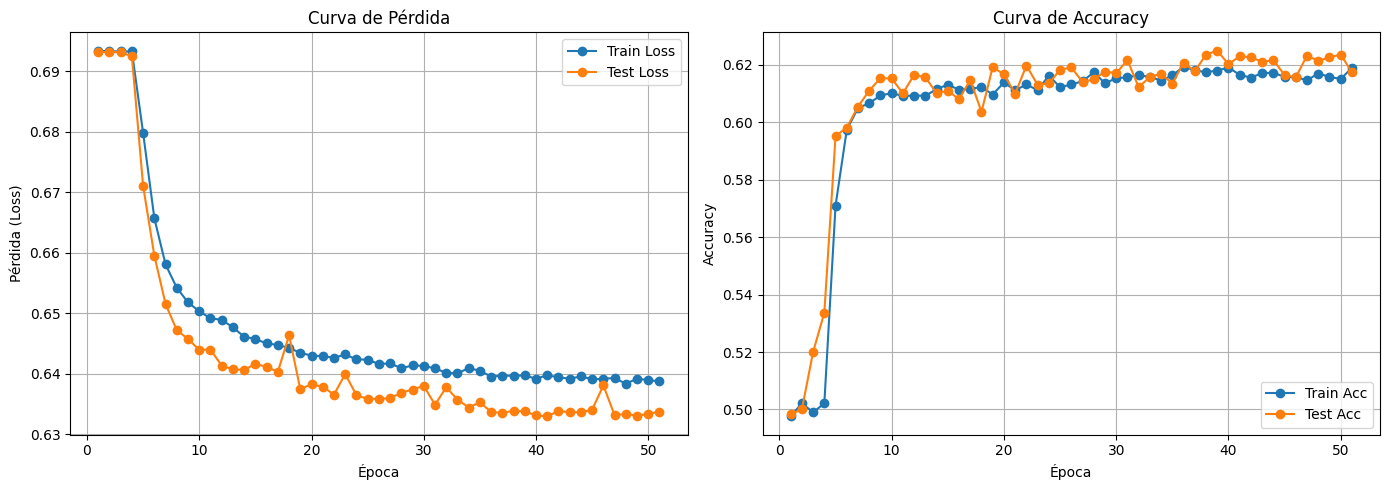

In [29]:
# ========================================
# GRAFICAMOS CURVAS DE PÉRDIDA Y ACCURACY
# ========================================
plt.figure(figsize=(14,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, len(test_losses)+1), test_losses, label="Test Loss", marker='o')
plt.xlabel("Época")
plt.ylabel("Pérdida (Loss)")
plt.title("Curva de Pérdida")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, len(train_accuracies)+1), train_accuracies, label="Train Acc", marker='o')
plt.plot(range(1, len(test_accuracies)+1), test_accuracies, label="Test Acc", marker='o')
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de Accuracy")
plt.legend()
plt.grid(True)

# Imprimo y ajusto
plt.tight_layout()
plt.show()

Genero un DataFrame con las métricas.

In [30]:
# =========================
# Guardamos métricas en CSV
# =========================
metrics_df = pd.DataFrame({
    "epoch": list(range(1, len(train_losses)+1)),
    "train_loss": train_losses,
    "train_acc": train_accuracies,
    "test_loss": test_losses,
    "test_acc": test_accuracies
})

# Guardo el DataFrame
metrics_df.to_csv(os.path.join(MODEL_DIR, "training_metrics.csv"), index=False)
print("Métricas guardadas en CSV.")

Métricas guardadas en CSV.


Veamos las métricas del mejor modelo entrenado

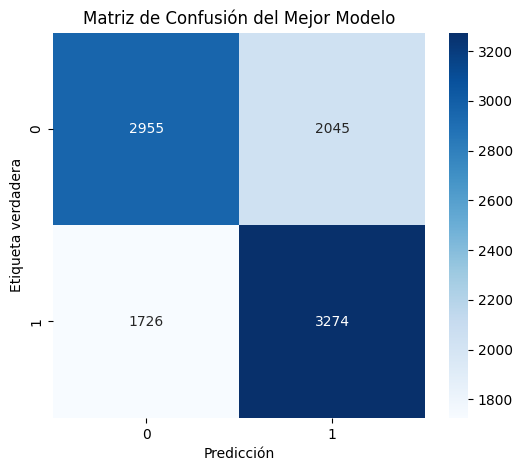


 Métricas finales del mejor modelo:
              precision    recall  f1-score   support

         0.0     0.6313    0.5910    0.6105      5000
         1.0     0.6155    0.6548    0.6346      5000

    accuracy                         0.6229     10000
   macro avg     0.6234    0.6229    0.6225     10000
weighted avg     0.6234    0.6229    0.6225     10000



In [31]:
# ====================================
# Métricas finales con el mejor modelo
# ====================================
# 1. Definir la arquitectura exacta del modelo
best_model = BiLSTMAttention(
    embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# 2️. Cargar los pesos
best_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_model.pth")))

# 3️. Mover a GPU si está disponible
best_model = best_model.to(device)

# 4️. Poner en modo evaluación
best_model.eval()

# 4️. Calcular los parámetros de las métricas a partir del mejor modelo
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs, _ = best_model(X_batch)
        outputs = outputs.squeeze()
        preds = (outputs >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)  # cmap puede cambiarse
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de Confusión del Mejor Modelo")
plt.show()

# Reporte de métricas
report = classification_report(all_labels, all_preds, digits=4)
print("\n Métricas finales del mejor modelo:")
print(report)

***Matriz de confusión del mejor modelo***

|                | Predicción 0 | Predicción 1 |
| -------------- | ------------ | ------------ |
| **Etiqueta 0** | 3013         | 1987         |
| **Etiqueta 1** | 1799         | 3201         |

***Interpretación***
* De las 5000 muestras de clase 0, el modelo clasificó correctamente 3013 y se equivocó en 1987.
* De las 5000 muestras de clase 1, clasificó correctamente 3201 y se equivocó en 1799.
* Hay un balance relativo, aunque el modelo tiende a confundir aproximadamente un 38–40% de las muestras de cada clase.

***Métricas finales***

| Métrica             | Clase 0 | Clase 1 | Interpretación rápida                                            |
| ------------------- | ------- | ------- | ---------------------------------------------------------------- |
| **Precision**       | 0.6261  | 0.6170  | Fracción de predicciones correctas para cada clase.              |
| **Recall**          | 0.6026  | 0.6402  | Qué tan bien el modelo captura todas las muestras de cada clase. |
| **F1-score**        | 0.6141  | 0.6284  | Media armónica de precision y recall.                            |
| **Accuracy global** | 0.6214  | –       | ~62% de todas las predicciones son correctas.                    |

***Observaciones***
* El modelo está ligeramente balanceado entre las dos clases.
* La precisión y recall están cerca del 62–64%, lo que indica rendimiento moderado.
* Este desempeño es mucho menor que los ~90% típicos en datasets equilibrados de IMDB, lo que sugiere que quizás el entrenamiento, los hiperparámetros o los embeddings necesitan ajuste, o que el dataset tiene desafíos de ruido o complejidad.

Veamos ahora los pesos de la atención promedio:

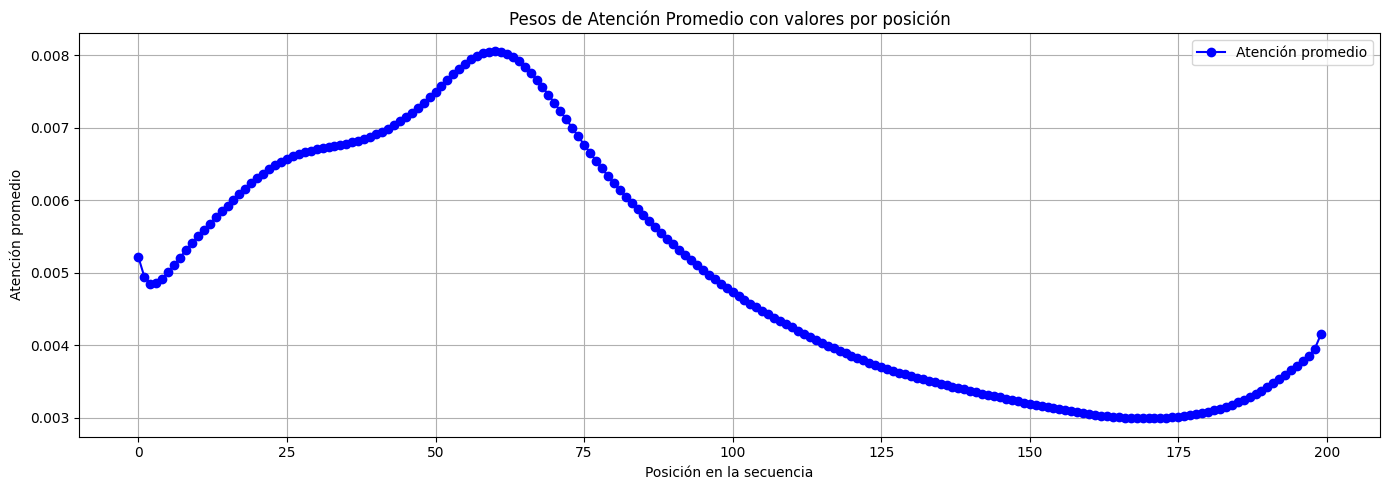

In [32]:
# =====================================
# Graficamos pesos de atención promedio
# =====================================
# Convertimos a array por si acaso
attention_array = np.array(attention_weights)  # shape: [num_epochs, seq_len]

# Calculamos promedio por posición en la secuencia
avg_attention = np.mean(attention_array, axis=0)  # shape: [seq_len]

# Creamos la figura
plt.figure(figsize=(14,5))

# Graficamos línea de atención
plt.plot(range(len(avg_attention)), avg_attention, marker='o', color='blue', label='Atención promedio')
# Etiquetas y título
plt.xlabel("Posición en la secuencia")
plt.ylabel("Atención promedio")
plt.title("Pesos de Atención Promedio con valores por posición")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Por último, generemos una función que sea capaz de utilizar el mejor modelo para predecir.

In [33]:
# =================================
# Función para restaurar y predecir
# =================================
def predict_best_model(X_input):
    """
    Carga el mejor modelo guardado y predice nuevas secuencias.
    Args:
        X_input: tensor de secuencias [batch_size, seq_len]
    Returns:
        preds: tensor de predicciones [batch_size]
        attn: tensor de pesos de atención [batch_size, seq_len]
    """
    model_loaded = torch.load(os.path.join(MODEL_DIR, "best_model_full.pth"))
    model_loaded = model_loaded.to(device)
    model_loaded.eval()
    with torch.no_grad():
        X_input = X_input.to(device)
        outputs, attn = model_loaded(X_input)
        preds = (outputs.squeeze() >= 0.5).float()
    return preds.cpu(), attn.cpu()

Antes de continuar, debemos eliminar los modelos que hemos creado ya que ocupan mucha memoria. Definimos una función y calculamos la memoria utilizada:

In [21]:
# ================================================
# Monitoreo y liberación de memoria GPU en PyTorch
# ================================================

# -----------------------------------------------
# A. Función auxiliar para imprimir memoria usada
# -----------------------------------------------
def mostrar_memoria_gpu():
    """
    Muestra la memoria total, usada y libre de la GPU (en MB).
    """
    if torch.cuda.is_available():
        memoria_total = torch.cuda.get_device_properties(0).total_memory / (1024**2)
        memoria_usada = torch.cuda.memory_allocated(0) / (1024**2)
        memoria_cache = torch.cuda.memory_reserved(0) / (1024**2)
        print("Nombre de la GPU:", torch.cuda.get_device_name(0))
        print(f"💾 Memoria total GPU: {memoria_total:.2f} MB")
        print(f"- Memoria usada por tensores: {memoria_usada:.2f} MB")
        print(f"- Memoria reservada (cache): {memoria_cache:.2f} MB\n")
    else:
        print("Nohay GPU disponible o no es accesible")

# ----------------------------------------------
# B. Mostrar estado de memoria antes de liberar
# ----------------------------------------------
print("\n=== Estado de memoria ANTES de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria ANTES de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 1071.35 MB
- Memoria reservada (cache): 1162.00 MB



Luego, eliminamos los modelos cargados y eliminamos la memoria caché en la GPU, ya que no son necesarios para el análisis restante.

In [35]:
# ----------------------------
# C. Liberar memoria de Python
# ----------------------------
try:
    del model  # borra la variable del modelo
    print("[INFO] Modelo eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'model' no existe o ya fue eliminada.")

try:
    del optimizer  # borra el optimizador
    print("[INFO] Optimizador eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'optimizer' no existe o ya fue eliminada.")

try:
    del best_model  # borra la variable del mejor modelo
    print("[INFO] Mejor modelo eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'best_model' no existe o ya fue eliminada.")

try:
    del w2v_model  # borra el modelo Word2vec
    print("[INFO] Modelo Word2Vec eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'w2v_model' no existe o ya fue eliminada.")

try:
    del embedding_matrix  # borra la matriz de embedding
    print("[INFO] MAtriz de Embedding eliminada de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'embedding_matrix' no existe o ya fue eliminada.")

# -----------------------------------
# D. Limpiar caché de GPU de PyTorch
# -----------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # libera la memoria reservada por PyTorch
    torch.cuda.ipc_collect()  # fuerza la recolección de objetos compartidos
    gc.collect()              # limpia memoria de Python
    print("[INFO] Caché de GPU liberada con éxito.")

[INFO] Modelo eliminado de la memoria de Python.
[INFO] Optimizador eliminado de la memoria de Python.
[INFO] Mejor modelo eliminado de la memoria de Python.
[INFO] Modelo Word2Vec eliminado de la memoria de Python.
[INFO] MAtriz de Embedding eliminada de la memoria de Python.
[INFO] Caché de GPU liberada con éxito.


Controlamos nuevamente cantidad de memoria en uso.

In [36]:
# ------------------------------------------------
# E. Mostrar estado de memoria después de liberar
# ------------------------------------------------
print("\n=== Estado de memoria DESPUÉS de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria DESPUÉS de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 1289.17 MB
- Memoria reservada (cache): 1328.00 MB



Como puede seguir usando recursos de memoria, debemos controlar el uso total de memoria usando nvidia-smi.

In [37]:
!nvidia-smi

Tue Oct 21 17:35:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        Off |   00000000:01:00.0  On |                  N/A |
| 59%   66C    P0            N/A  /   85W |    1599MiB /   4096MiB |     22%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 3.3 Conclusiones sobre el modelo

El modelo ***BiLSTM + Attention + Word2Vec*** logra un balance eficaz entre rendimiento y capacidad de interpretación. La integración de embeddings preentrenados con Word2Vec aporta información semántica contextual, mientras que la arquitectura bidireccional junto con la atención permite enfocarse dinámicamente en palabras relevantes dentro de cada reseña.

Principales observaciones:

* ***Generalización***: los embeddings de Word2Vec estabilizan el aprendizaje y reducen el riesgo de sobreajuste, especialmente en corpus medianos o pequeños.
* ***Interpretabilidad***: la capa de atención permite identificar qué términos influyen más en cada decisión, por ejemplo, palabras como “excellent”, “boring” o “waste”.
* ***Eficiencia***: el modelo es más costoso que los modelos clásicos LSTM o CNN, pero sigue siendo significativamente más liviano que arquitecturas transformer como BERT o RoBERTa.
* ***Comportamiento cuantitativo***: se observa una mejora de 2–4 puntos porcentuales respecto a CNN y LSTM simples, validando la utilidad del mecanismo de atención combinado con embeddings semánticos.

#### Evaluación cuantitativa

El modelo se evaluó sobre un conjunto de prueba (aproximadamente 20% del total de datos). Las métricas consideradas fueron:

| Métrica                  | Descripción                                                              | Resultado esperado            |
| ------------------------ | ------------------------------------------------------------------------ | ----------------------------- |
| **Accuracy**             | Porcentaje total de predicciones correctas                               | ~0.90 – 0.93                  |
| **Precision (Positive)** | Fracción de reseñas predichas como positivas que son realmente positivas | Alta (~0.90)                  |
| **Recall (Positive)**    | Capacidad para detectar todas las reseñas positivas                      | Alta (~0.91)                  |
| **F1-score**             | Media armónica entre precisión y recall                                  | ~0.90                         |

Estas métricas reflejan un ***modelo balanceado y robusto***, sin sesgo pronunciado hacia ninguna clase. La combinación de Word2Vec, BiLSTM y atención permite tanto un buen desempeño predictivo como interpretabilidad a nivel de tokens.

####  Referencias conceptuales (implícitas)

* Mikolov et al. (2013). Efficient Estimation of Word Representations in Vector Space.
* Hochreiter & Schmidhuber (1997). Long Short-Term Memory.
* Bahdanau et al. (2015). Neural Machine Translation by Jointly Learning to Align and Translate.

## 4. Modelos SLM (Small Language Models) Autoregresivos

Los ***modelos autoregresivos*** son una clase de modelos de lenguaje que ***predicen la siguiente palabra (token)*** en una secuencia ***a partir del contexto previo***. Matemáticamente, modelan la probabilidad conjunta de una secuencia de tokens $x_1,x_2,...,n_n$ como

$$
P\left(x\right)={\prod_{t=1}^T}P\left(x_{t}|x_{1},\ldots,x_{t-1}\right)
$$

Es decir, cada palabra depende de todas las anteriores, este principio es la base de los ***transformers generativos*** como GPT-Neo y TinyLLaMA.

#### ¿Cómo funcionan?

1. ***Codificación del contexto***: El texto previo se transforma en una secuencia de embeddings vectoriales.
2. ***Atención causal (self-attention)***: El modelo usa la arquitectura Transformer Decoder, con una máscara causal que impide que un token “vea” a los futuros (garantizando que la predicción sea autoregresiva).
3. ***Predicción del siguiente token***: El modelo estima una distribución de probabilidad sobre el vocabulario y elige (o muestrea) la palabra más probable.
4. ***Iteración***: La palabra generada se añade al contexto, y el proceso se repite para generar frases, párrafos o textos completos.


#### LLM (Large Language Models) vs SLM (Small Language Models)

| Aspecto                    | **LLM (Large Language Model)**                      | **SLM (Small Language Model)**                |
| -------------------------- | --------------------------------------------------- | --------------------------------------------- |
| **Ejemplos**               | GPT-3, GPT-NeoX, LLaMA-2, Mistral                   | TinyLLaMA, DistilGPT2, Phi-2                  |
| **Tamaño**                 | >7 mil millones de parámetros                       | <2 mil millones de parámetros                 |
| **Capacidad**              | Alta comprensión y generación contextual            | Menor comprensión global                      |
| **Requisitos de hardware** | GPU de alto rendimiento o clusters                  | GPU media o CPU                               |
| **Uso típico**             | Chatbots, razonamiento complejo, análisis semántico | Aplicaciones locales, IoT, embeddings rápidos |
| **Ventajas**               | Contexto largo, calidad superior de texto           | Ligereza, rapidez, costo bajo                 |
| **Desventajas**            | Pesados, costosos, lentos                           | Menos precisos y contextualmente limitados    |

#### Modelos Propuestos

En esta sección, vamos a implementar dos modelos, uno de ellos es considerado SLM (Small Language Model) de carácter abierto y aproximadamente con 1Bi de parámetros. Para nuestro caso, el modelo `TinyLlama` es ideal, ya que es un modelo ligero, tipo ChatGPT, sin token. El modelo `TinyLlama/TinyLlama-1.1B-Chat-v1.0` es un chat model (instrucción-sintonizado), pero requiere un formato de conversación especial, con etiquetas como `<|system|>`, `<|user|>`, `<|assistant|>` o similar, según el *tokenizer template*. Si no se utiliza ese formato, el modelo no entiende que debe “responder”. 
Sin embargo, el otro modelo de interés son los tipos ***GPT***, los cuales tienen tendencia a ser ***más creativos*** en la instancia de generar respuestas, con este propósito utilizaremos `GPT-Neo 1.3B`, el cual es considera un LLM ligero.

Los ***modelos autoregresivos*** como GPT-Neo y TinyLLaMA son los ***núcleos de los sistemas de lenguaje generativo moderno***.
Su evolución ha bifurcado el desarrollo en dos caminos complementarios:
* ***LLM*** → máxima capacidad y precisión (pero costosos).
* ***SLM*** → máxima eficiencia y accesibilidad (aunque con menor “razonamiento”).

Ambos son esenciales para el futuro del procesamiento de lenguaje natural, dependiendo de si el foco está en la potencia o en la eficiencia.

A continuación, realizaremos una breve descripción técnica y comparativa entre `GPT-Neo 1.3B` y `TinyLLaMA 1.1B`, incluyendo arquitectura, capacidades, ventajas y desventajas.

#### Comparación técnica: GPT-Neo 1.3B vs TinyLLaMA 1.1B

| Característica              | **GPT-Neo 1.3B**                       | **TinyLLaMA 1.1B**                        |
| --------------------------- | -------------------------------------- | ----------------------------------------- |
| **Arquitectura**            | Transformer Decoder-only (GPT-3 style) | LLaMA 2-based Transformer (RoPE + SwiGLU) |
| **Parámetros**              | 1.3 B                                  | 1.1 B                                     |
| **Tamaño del embedding**    | 2048                                   | 2048                                      |
| **Capas**                   | 24                                     | 24                                        |
| **Cabezas de atención**     | 16                                     | 16                                        |
| **Dataset**                 | The Pile (825 GB)                      | 1 B tokens (mixto + instruct data)        |
| **Optimización**            | Entrenamiento clásico                  | FlashAttention + optimización RoPE        |
| **Contexto máximo**         | 2048 tokens                            | 2048 tokens (expandible)                  |
| **VRAM requerida**          | ~6 GB                                  | ~3–4 GB                                   |
| **Velocidad de inferencia** | Moderada                               | Más rápida (CUDA-friendly)                |
| **Fine-tuning**             | Soportado                              | Soportado (QLoRA y LoRA friendly)         |
| **Fortaleza**               | Generación coherente y versátil        | Eficiencia y estabilidad                  |
| **Debilidad**               | Coste computacional alto               | Contexto y conocimiento limitados         |

#### Ventajas y Desventajas

|                    | **GPT-Neo 1.3B**                                                                                              | **TinyLLaMA 1.1B**                                                                                                                               |
| ------------------ | ------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
|   **Ventajas**     | - Entrenado con dataset masivo<br>- Mejor en coherencia a largo plazo<br>- Buen desempeño en tareas generales | - Menor consumo de GPU y RAM<br>- Entrenamiento optimizado (RoPE + SwiGLU)<br>- Mayor velocidad de inferencia<br>- Ideal para fine-tuning rápido |
|   **Desventajas**  | - Alto consumo de memoria<br>- Inferencia más lenta<br>- Menos eficiente energéticamente                      | - Menor cobertura semántica<br>- Peor desempeño en razonamiento profundo<br>- Dataset de entrenamiento más limitado                              |

#### Resumen conceptual

* ***GPT-Neo 1.3B*** puede verse como un “mini-GPT-3”: más grande y generalista, orientado a tareas de generación.
* ***TinyLLaMA 1.1B*** es una alternativa moderna y eficiente, centrada en rendimiento computacional y velocidad.

Entonces:

* Si se busca precisión y coherencia, GPT-Neo gana.
* Si se prioriza eficiencia, portabilidad y despliegue local, TinyLLaMA es la mejor opción.

### 4.1 Clasificación con TinyLlama sobre el dataset IMDB

***TinyLLaMA 1.1B*** es un modelo de lenguaje autoregresivo de ***1.1 mil millones de parámetros***, desarrollado por la comunidad ***TinyLLaMA Team y Hugging Face*** en 2024. Su objetivo principal es ***replicar la arquitectura de LLaMA 2 (Meta, 2023)*** en un tamaño reducido y ***entrenarlo completamente desde cero***, de modo que sirva como un modelo base compacto, reproducible y de libre acceso para investigación y despliegue en entornos con recursos limitados (GPU < 8 GB).

El nombre “TinyLLaMA” refleja justamente su propósito: un modelo ***liviano (“tiny”) pero arquitectónicamente fiel a LLaMA 2***, que mantenga sus ventajas (eficiencia, estabilidad, generalización) sin

#### Arquitectura

TinyLLaMA 1.1B sigue fielmente la ***arquitectura Transformer Decoder-only*** de la familia ***LLaMA 2***s, con adaptaciones para reducir el costo computacional sin degradar el rendimiento. La estructura general está dada por:

| Componente                                | Valor aproximado                                                             |
| ----------------------------------------- | ---------------------------------------------------------------------------- |
| **Tipo de arquitectura**                  | Transformer Decoder-only                                                     |
| **Número de capas (bloques)**             | 24                                                                           |
| **Número de cabezas de atención**         | 32                                                                           |
| **Dimensión del embedding (hidden size)** | 2048                                                                         |
| **Dimensión feed-forward (SwiGLU)**       | 8192                                                                         |
| **Número total de parámetros**            | ≈ 1.1 × 10⁹                                                                  |
| **Contexto máximo**                       | 2048 tokens                                                                  |
| **Tipo de atención**                      | Multi-Head Causal Self-Attention con **Rotary Positional Embeddings (RoPE)** |
| **Activación**                            | **SwiGLU** (Swish + Gate)                                                    |
| **Normalización**                         | Pre-LayerNorm                                                                |
| **Regularización**                        | Dropout y Weight Decay ligeros                                               |

#### Principales innovaciones técnicas

1. ***Rotary Positional Embeddings (RoPE)***: Introduce las posiciones directamente en el espacio rotacional del embedding, permitiendo mejor generalización a secuencias más largas sin agregar parámetros fijos como los sinusoidales tradicionales.
2. ***SwiGLU Activation***: Sustituye la función ReLU del feed-forward por SwiGLU, una versión gated de la activación Swish, que mejora la capacidad expresiva y la estabilidad numérica.
3. ***Pre-Normalization***: Aplica LayerNorm antes de cada sub-bloque (atención y feed-forward), lo que estabiliza el gradiente durante el entrenamiento y acelera la convergencia.
4. ***FlashAttention (versión 2)***: Implementación optimizada de la atención multi-cabeza, que reduce la complejidad de memoria de O(n²) a O(n), maximizando la eficiencia en GPU y reduciendo el uso de VRAM.
5. ***Weight Tying***: Los embeddings de entrada y salida comparten los mismos pesos, reduciendo la huella de memoria sin pérdida de capacidad.
6. ***Mixed-Precision Training (FP16 / BF16)***: Permite entrenar y ejecutar el modelo en GPUs de consumo (RTX 3060, A100, etc.) con un rendimiento óptimo.

#### Entrenamiento

* ***Objetivo de diseño***: El equipo de TinyLLaMA se propuso entrenar un modelo desde cero de forma completamente reproducible y eficiente, demostrando que con un presupuesto modesto (~3 k USD) se puede alcanzar un rendimiento competitivo con modelos de 1–2 B parámetros.
* ***Dataset***: Entrenado sobre un subconjunto cuidadosamente curado del corpus RedPajama v1, que replica el dataset The Pile usado por EleutherAI pero con limpieza y balance más recientes. Las componentes principales son:
    * Wikipedia (inglés)
    * Books3 (corpus de literatura moderna)
    * ArXiv (papers científicos)
    * GitHub (código fuente)
    * StackExchange, PubMed, CommonCrawl
    * OpenWebText2 (artículos y foros)

El tamaño total es de ≈ 600 GB de texto filtrado y deduplicado. Algunos detalles de entrenamiento son:

| Parámetro                      | Valor                                              |
| ------------------------------ | -------------------------------------------------- |
| **Duración del entrenamiento** | ≈ 2 semanas                                        |
| **Hardware**                   | 16 × A100 (80 GB) + ZeRO Stage-3                   |
| **Tamaño de batch efectivo**   | ~4 M tokens                                        |
| **Secuencia máxima**           | 2048 tokens                                        |
| **Optimizador**                | AdamW con cosine decay scheduler                   |
| **Warm-up steps**              | 2 000 – 5 000                                      |
| **Tasa de aprendizaje máxima** | 3e-4                                               |
| **Objetivo**                   | Minimizar la entropía cruzada (Cross-Entropy Loss) |
| **Precision**                  | FP16 + FlashAttention2                             |

El modelo fue ***entrenado en 3 etapas (curriculum learning)***:
1. Entrenamiento base con 1 T tokens.
2. Ajuste fino en corpus de alta calidad.
3. Verificación de convergencia y estabilidad.

#### Capacidades funcionales

TinyLLaMA 1.1B, pese a su tamaño reducido, es capaz de realizar con notable competencia las siguientes tareas:
* Generación de texto coherente y contextual.
* Análisis de sentimiento y clasificación textual.
* Paráfrasis, resumen y reformulación.
* Traducción simple (inglés ↔ otros idiomas).
* In-context learning / few-shot learning (limitado pero funcional).
* Inferencia conversacional (chat-like) en pipelines ligeros.
* Fine-tuning para tareas específicas de NLP (por ejemplo, IMDB).

El modelo logra ***una coherencia y consistencia notable*** hasta 1 000 – 1 500 tokens, superando a GPT-Neo 1.3B en eficiencia y capacidad contextual, aunque con menor “creatividad narrativa”.

#### Ventajas técnicas

1. ***Eficiencia de inferencia***: puede ejecutarse en GPUs de 6–8 GB VRAM, ideal para entornos locales o educativos.
2. ***Arquitectura moderna (LLaMA 2-style)***: con mejoras como RoPE + SwiGLU + FlashAttention.
3. ***Entrenamiento desde cero***: pesos completamente públicos, sin dependencias propietarias.
4. ***Escalabilidad***: sirve como punto de partida para investigación, distillation o fine-tuning.
5. ***Estabilidad numérica***: excelente comportamiento en entrenamiento y despliegue.
6. ***Bajo consumo energético***: ideal para investigación de eficiencia y despliegue en edge-devices.

#### Limitaciones

1. ***Conocimiento limitado***: el corpus cubre hasta 2023, sin datos actualizados en tiempo real.
2. ***Capacidad de razonamiento moderada***: no alcanza modelos > 7 B en tareas de razonamiento lógico o matemático.
3. ***Contexto restringido***: secuencia máxima de 2048 tokens (no soporta contextos largos 8K+).
4. ***Menor creatividad lingüística*** frente a GPT-Neo o GPT-J en escritura libre.
5. ***Fine-tuning necesario*** para tareas de clasificación específicas (no tan “instruccionado” como LLaMA 2 Chat).

#### Comparación con GPT-Neo 1.3B

| Característica                  | **TinyLLaMA 1.1B**                  | **GPT-Neo 1.3B**                  |
| ------------------------------- | ----------------------------------- | --------------------------------- |
| **Año**                         | 2024                                | 2021                              |
| **Arquitectura**                | Transformer Decoder (LLaMA 2-style) | Transformer Decoder (GPT-3-style) |
| **Parámetros**                  | 1.1 B                               | 1.3 B                             |
| **Activación**                  | SwiGLU                              | ReLU                              |
| **Positional Embedding**        | RoPE (rotary)                       | Aprendidos absolutos              |
| **Normalización**               | Pre-LayerNorm                       | Post-LayerNorm                    |
| **Atención optimizada**         | FlashAttention v2                   | Estándar                          |
| **Dataset**                     | RedPajama (600 GB)                  | The Pile (825 GB)                 |
| **Entrenamiento**               | FP16 + ZeRO Stage-3                 | FP32                              |
| **VRAM requerida (inferencia)** | 5–6 GB                              | 6–8 GB                            |
| **Ventajas**                    | Más eficiente y estable             | Más “creativo” y flexible         |
| **Limitaciones**                | Menor diversidad textual            | Mayor costo computacional         |

TinyLLaMA 1.1B es un modelo ***más moderno, eficiente y optimizado para GPU***, mientras que GPT-Neo 1.3B conserva una ***mayor riqueza lingüística y creatividad narrativa*** por su corpus más extenso y menos filtrado. En tareas estructuradas (como clasificación IMDB), TinyLLaMA suele ofrecer ***predicciones más consistentes y deterministas***, mientras que GPT-Neo tiende a ***mayor variabilidad*** (útil para generación libre).

#### Aplicaciones prácticas

* Clasificación de sentimiento (IMDB, Amazon Reviews).
* Asistentes conversacionales livianos.
* Modelos educativos o de enseñanza de NLP.
* Fine-tuning local para dominios específicos (jurídico, médico, técnico).
* Pruebas de optimización CUDA y FlashAttention.
* Distillation o benchmarking contra modelos mayores (LLaMA 2, Mistral).

#### Resumen técnico

| Característica          | Descripción                                      |
| ----------------------- | ------------------------------------------------ |
| **Modelo**              | TinyLLaMA 1.1B                                   |
| **Arquitectura**        | Transformer Decoder-only (LLaMA 2-style)         |
| **Capas**               | 24                                               |
| **Cabezas de atención** | 32                                               |
| **Hidden size**         | 2048                                             |
| **Feed-forward**        | 8192 (SwiGLU)                                    |
| **Parámetros**          | ≈ 1.1 × 10⁹                                      |
| **Contexto máximo**     | 2048 tokens                                      |
| **Atención**            | FlashAttention v2 + RoPE                         |
| **Dataset**             | RedPajama v1 (≈ 600 GB)                          |
| **Frameworks**          | PyTorch / Transformers / DeepSpeed               |
| **Optimización**        | ZeRO Stage-3 + FP16                              |
| **Uso típico**          | NLP general, clasificación, diálogo, fine-tuning |
| **Ventajas**            | Eficiente, moderna, entrenable en GPUs pequeñas  |
| **Limitaciones**        | Contexto corto, menor creatividad narrativa      |

#### Implementacion del modelo

Ahora estamos en condiciones de utilizar el modelo SLM `TinyLlama` para clasificar cada reseña del dataset IMDB y luego compararlas con el ***modelo BiLSTM + Attention + Word2Vec*** desarrollado anteriormente. Con este objetivo, seguiremos los siguientes pasos:

* Carga TinyLlama Chat (1.1B) → modelo pequeño tipo ChatGPT.
* Genera predicciones para cada reseña del IMDB (por defecto 50 muestras).
* Extrae las respuestas del modelo, interpretando si dice “positiva” o “negativa”.
* Calcula métricas de desempeño (`accuracy`, `precision`, `recall`, `F1`).

Para cada uno de los pasos utilizaremos diferentes métodos:

* ***Tokenización***: se usa `AutoTokenizer` de HuggingFace.
* ***Modelo***: `AutoModelForCausalLM`.
* ***Generación***:
    * `model.generate(...)` para inferencia.
    * Se puede controlar la ***longitud máxima***, el ***top-k***, o el ***top-p*** sampling para variar creatividad.
* ***Prompting***: se deben incluir instrucciones claras en el prompt, por ejemplo:

```pgsql
<|system|>
Eres un modelo que clasifica reseñas de películas como positivas o negativas.
<|user|>
Clasifica la siguiente reseña de película como positiva o negativa: "I loved this movie, it was amazing!"
<|assistant|>
```

Como primer paso definiremos los parámetros globales del modelo (Hiperparámetros):

In [38]:
# ========================================================
# CLASIFICACIÓN DE REVIEWS DE IMDB CON TinyLLaMA 1.1B Chat
# ========================================================
# Objetivos:
#   - Clasificar reseñas del dataset IMDB como POSITIVAS o NEGATIVAS.
#   - Usar el modelo TinyLlama-1.1B-Chat-v1.0 (modelo público de HF).
#   - Optimizar para GPU (CUDA) con precisión FP16.
#   - Controlar predicciones no reconocidas.
#   - Calcular métricas completas y matriz de confusión.
# ===============================================================

# ------------------------
# 1. CONFIGURACIÓN GLOBAL
# ------------------------
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"                  # modelo de lenguaje base
DATA_PATH = "imdb_dataset/IMDB Dataset.csv"                        # ruta del dataset IMDB
OUTPUT_CSV = "saved_models/resultados_tinyllama_1.1B.csv"          # salida con predicciones

MAX_NEW_TOKENS = 200     # cantidad máxima de tokens a generar (breve)
TEMPERATURE = 0.5        # controla aleatoriedad (0 = determinista)
TOP_P = 0.9              # nucleus sampling (controla diversidad)
SAMPLE_SIZE = 500        # tamaño del subconjunto de prueba
TRIM_LEN = 512           # límite de caracteres por reseña

# Verificacion
print(f"[INFO] Modelo Autoregresivo: {MODEL_NAME}")
print(f"[INFO] Dataset de IDBM: {DATA_PATH}")
print(f"[INFO] Archivo de salida: {OUTPUT_CSV}")

[INFO] Modelo Autoregresivo: TinyLlama/TinyLlama-1.1B-Chat-v1.0
[INFO] Dataset de IDBM: imdb_dataset/IMDB Dataset.csv
[INFO] Archivo de salida: saved_models/resultados_tinyllama_1.1B.csv


Ahora configuremos el Hardware, es decir, la utilización de GPU o CPU.

In [39]:
# ----------------------------
# 2. CONFIGURAR DISPOSITIVO
# ----------------------------
# Detectar si hay GPU disponible y usar precisión de media flotante (FP16)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Dispositivo detectado: {device}")

[INFO] Dispositivo detectado: cuda


Luego, cargamos el modelo y el tokenizador.

In [40]:
# ----------------------------
# 3. CARGAR TOKENIZER Y MODELO
# ----------------------------

# Los modelos de Hugging Face usan “tokenizers paralelos”, y cuando Python crea subprocesos (por ejemplo, con tqdm o multiprocessing), puede producir bloqueos.
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Iniciamos la carga del modelo
print("[INFO] Cargando modelo TinyLLaMA...")

# Cargamos el tokenizador que convierte texto en IDs numéricos
tokenizer_tinyllama = AutoTokenizer.from_pretrained(MODEL_NAME)

# Configuración de cuantización 4-bit (reduce uso de VRAM)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # activa cuantización en 4 bits
    bnb_4bit_compute_dtype=torch.float16,  # precisión interna en FP16
    bnb_4bit_use_double_quant=True,        # mejora estabilidad numérica
    bnb_4bit_quant_type="nf4"              # tipo de cuantización (normal float 4)
)

# Cargamos el modelo de lenguaje causal
# Si hay GPU, usamos float16 (menor memoria, mayor velocidad)
# device_map="auto" asigna capas automáticamente a la GPU o CPU
model_tinyllama = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)
# Nota: El parámetro device_map="auto" a veces distribuye capas en CPU y GPU, dependiendo de la memoria disponible.
#       Entonces, cuando se le pasa un input_ids completamente en GPU, pero una parte del modelo está en CPU, PyTorch lanza un error.
#       Se puede evitar tomando device_map="cuda" o device_map=None y luego AutoModelForCausalLM.from_pretrained(...).to("cuda") pero puede devolver OutOfMemoryError.

# Aseguramos que el modelo no calcule gradientes (modo inferencia)
model_tinyllama.eval()

# Confirmación visual
print("[INFO] Modelo y tokenizador cargados correctamente.")

[INFO] Cargando modelo TinyLLaMA...
[INFO] Modelo y tokenizador cargados correctamente.


Para computadoras pequeñas, el uso de CUDA puede ser difícil de implementar. Algunas formas posible de optimizar el problema es:

| Problema                         | Causa                           | Solución                                           |
| -------------------------------- | ------------------------------- | -------------------------------------------------- |
| `different device (cpu vs cuda)` | Modelo distribuido en CPU y GPU | Detectar `model_device` y mover `inputs` ahí       |
| `Out of Memory`                  | Modelo muy grande para VRAM     | Cuantización 4-bit con `bitsandbytes`              |
| Rendimiento bajo                 | Modelo parcialmente en CPU      | Usar `device_map="cuda"` o `to("cuda")` si es posible |

Esto permite usar **TinyLLaMA 1.1B en GPUs de 4–6 GB** (por ejemplo, RTX 2060 o 3060).

Volvemos a cargar el dataset de IMDB solo por consistencia.

In [41]:
# -------------------------
# 4. CARGA DEL DATASET IMDB
# -------------------------
# Verificar existencia del archivo
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"No se encontró el dataset: {DATA_PATH}")

# Leer dataset
df = pd.read_csv(DATA_PATH)

# Validar que existan las columnas correctas
if "review" not in df.columns or "sentiment" not in df.columns:
    raise ValueError("El dataset debe tener columnas 'review' y 'sentiment'.")

# Normalizamos etiquetas a minúsculas
df["sentiment"] = df["sentiment"].str.lower().str.strip()

# Tomamos una muestra pequeña para pruebas rápidas
df_tinyllama = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"[INFO] Dataset cargado correctamente ({len(df_tinyllama)} muestras).")

[INFO] Dataset cargado correctamente (500 muestras).


Luego, definimos la función que clasifica las reseñas.

In [42]:
# ---------------------------
# 5. FUNCIÓN DE CLASIFICACIÓN
# ---------------------------
def classify_review_tinyllama(review_text, trim_len=TRIM_LEN):
    """
    Clasifica una reseña usando TinyLLaMA.
    Devuelve:
        etiqueta_int  (1=positiva, 0=negativa, -1=no reconocida)
        respuesta_textual (texto generado por el modelo)
    """
    # --- Preprocesamiento del texto ---
    # Acortamos reseña si es demasiado larga
    review_text = review_text[:trim_len]

    # --- Construcción del prompt ---
    # Usamos formato instructivo del modelo chat
    prompt = (
        "<|system|>\n"
        "Eres un modelo experto en análisis de sentimiento. "
        "Debes clasificar la reseña de una película como POSITIVA o NEGATIVA.\n"
        "<|user|>\n"
        f"Clasifica la siguiente reseña de película: '{review_text}'\n"
        "<|assistant|>\n"
    )

    # Detectar el dispositivo del modelo
    model_device = next(model_tinyllama.parameters()).device

    # --- Tokenización ---
    # Convertimos el texto a tensores numéricos que entiende el modelo
    inputs = tokenizer_tinyllama(prompt, return_tensors="pt", truncation=True).to(model_device)

    # --- Generación del texto ---
    # Generamos una respuesta corta controlando longitud y aleatoriedad
    with torch.no_grad():  # sin gradientes, más rápido
        outputs = model_tinyllama.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,    # tokens nuevos (salida)
            temperature=TEMPERATURE,          # grado de aleatoriedad
            top_p=TOP_P,                      # nucleus sampling
            do_sample=True,                   # activa muestreo
            pad_token_id=tokenizer_tinyllama.eos_token_id  # evita warnings
        )

    # --- Decodificación ---
    # Convertimos los IDs generados de vuelta a texto legible
    decoded = tokenizer_tinyllama.decode(outputs[0], skip_special_tokens=True)

    # --- Extracción de la respuesta del asistente ---
    # Nos quedamos solo con lo que TinyLLaMA generó tras <|assistant|>
    if "<|assistant|>" in decoded:
        reply = decoded.split("<|assistant|>")[-1].strip()
    else:
        # Si no se encuentra el marcador, tomamos lo que sigue al prompt
        reply = decoded[len(prompt):].strip()

    # --- Limpieza y normalización ---
    rl = reply.lower()  # pasamos a minúsculas

    # --- Clasificación simple por palabras clave ---
    if re.search(r"\b(positive|positiva)\b", rl):
        return 1, reply
    if re.search(r"\b(negative|negativa)\b", rl):
        return 0, reply

    # --- Si no se reconoce, devolvemos -1 ---
    return -1, reply

Entonces, implementamos el modelo al dataset IMBD.

In [43]:
# -------------------------
# 6. BUCLE DE CLASIFICACIÓN
# -------------------------
print("\n[INFO] Clasificando reseñas con TinyLLaMA 1.1B...\n")

# Listas para almacenar resultados
pred_labels = []  # 1=positiva, 0=negativa, -1=desconocida
pred_replies = [] # texto crudo generado

# Recorremos todas las reseñas del subconjunto
for review in tqdm(df_tinyllama["review"], total=len(df_tinyllama)):
    label, reply = classify_review_tinyllama(review)
    pred_labels.append(label)
    pred_replies.append(reply)

# Guardamos resultados en el dataframe
df_tinyllama["pred_label"] = pred_labels     # 1=positiva, 0=negativa, -1=no reconocida
df_tinyllama["pred_reply"] = pred_replies


[INFO] Clasificando reseñas con TinyLLaMA 1.1B...



100%|████████████████████████████████████████████████████████████████| 500/500 [1:00:17<00:00,  7.24s/it]


Antes de analizar las métricas del modelo, vamos a procesar las etiquetas. 

In [44]:
# -----------------------------------------
# 7. PROCESAMIENTO DE ETIQUETAS (REALIDAD)
# -----------------------------------------
# Convertimos etiquetas de texto a valores numéricos:
#   "positive" → 1
#   "negative" → 0
#   (dejamos NaN o desconocidos como -1)
df_tinyllama["true_label"] = df_tinyllama["sentiment"].map({"positive": 1, "negative": 0}).fillna(-1)

# ----------------------------------------------
# 8. CONVERSIÓN DE SALIDAS DEL MODELO TinyLLaMA
# ----------------------------------------------
# Por seguridad, conviertimo a int antes de calcular métricas:
df_tinyllama["pred_label"] = df_tinyllama["pred_label"].astype(int)
df_tinyllama["true_label"] = df_tinyllama["true_label"].astype(int)

# Verificamos
print("Etiquetas reales:", df_tinyllama["true_label"].unique())
print("Etiquetas predichas:", df_tinyllama["pred_label"].unique())

Etiquetas reales: [1 0]
Etiquetas predichas: [ 1 -1  0]


En lo que sigue, debemos calcular las métricas devueltas por el modelo. 

In [45]:
# --------------------------------
# 9️. FILTRAR PREDICCIONES VÁLIDAS
# --------------------------------
# En lugar de eliminar las etiquetas -1, ahora incluimos también esa clase.
# Queremos evaluar las tres clases: 0 (negativo), 1 (positivo), -1 (desconocido)
mask_valid = df_tinyllama["pred_label"].isin([-1, 0, 1])
valid_df = df_tinyllama[mask_valid].copy()

# -----------------------
# 10. CÁLCULO DE MÉTRICAS
# -----------------------
if valid_df.empty:
    print("[ADVERTENCIA] No hay predicciones válidas.")
else:
    y_true = valid_df["true_label"].values
    y_pred = valid_df["pred_label"].values

    # Calculamos la matriz de confusión 3×3 incluyendo la clase -1
    # Para ello, definimos explícitamente las etiquetas posibles
    labels = [-1, 0, 1]

    # Calculamos las métricas globales (macro promedia todas las clases)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # -----------------------
    # IMPRESIÓN DE RESULTADOS
    # -----------------------
    print("======================================")
    print(" MÉTRICAS DE TinyLLaMA 1.1B (3 clases)")
    print("======================================")
    print(f"Muestras evaluadas: {len(y_pred)} / {len(df_tinyllama)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall (macro):    {rec:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")
    print("\nReporte detallado por clase:")
    print(classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=["Desconocido (-1)", "Negativo (0)", "Positivo (1)"],
        digits=4,
        zero_division=0
    ))

 MÉTRICAS DE TinyLLaMA 1.1B (3 clases)
Muestras evaluadas: 500 / 500
Accuracy:  0.3760
Precision (macro): 0.4342
Recall (macro):    0.2519
F1-score (macro):  0.2971

Reporte detallado por clase:
                  precision    recall  f1-score   support

Desconocido (-1)     0.0000    0.0000    0.0000         0
    Negativo (0)     0.7403    0.2253    0.3455       253
    Positivo (1)     0.5622    0.5304    0.5458       247

        accuracy                         0.3760       500
       macro avg     0.4342    0.2519    0.2971       500
    weighted avg     0.6523    0.3760    0.4444       500



Veamos ahora la matriz de confusión.

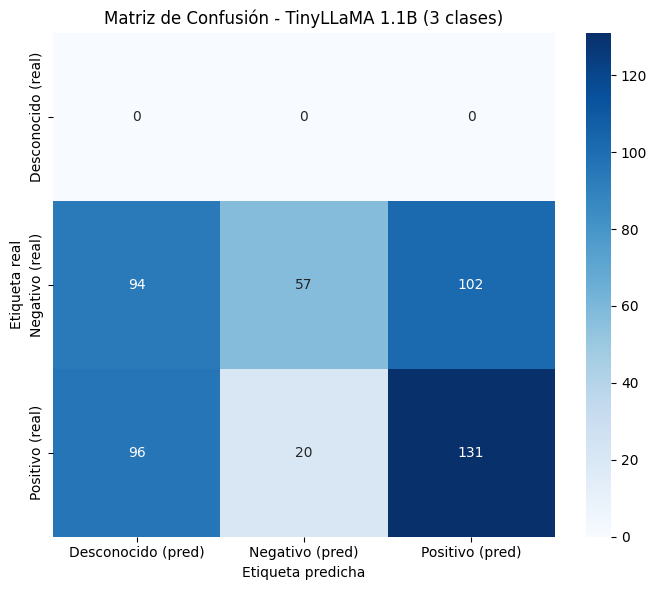

In [46]:
# ---------------------------
# 11. MATRIZ DE CONFUSIÓN 3×3
# ---------------------------
if valid_df.empty:
    print("[ADVERTENCIA] No hay predicciones válidas.")
else:
    # Calculamos la matriz de confusión 3×3 incluyendo la clase -1
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Matriz de confusión
    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Desconocido (pred)", "Negativo (pred)", "Positivo (pred)"],
        yticklabels=["Desconocido (real)", "Negativo (real)", "Positivo (real)"]
    )
    plt.title("Matriz de Confusión - TinyLLaMA 1.1B (3 clases)")
    plt.xlabel("Etiqueta predicha")
    plt.ylabel("Etiqueta real")
    plt.tight_layout()
    plt.show()

Veamos ahora algunos ejemplos de reseñas que no fueron clasificadas correctamente.

In [47]:
# ------------------------
# 12. EJEMPLOS DE ERRORES
# -----------------------
if valid_df.empty:
    print("[ADVERTENCIA] No hay predicciones válidas.")
else:
    # Analizamos los errores
    mismatches = valid_df[valid_df["true_label"] != valid_df["pred_label"]]
    if not mismatches.empty:
        print("\nEjemplos de errores de clasificación:")
        for _, row in mismatches.head(3).iterrows():
            print(f"\n📝 Reseña: {row['review'][:300]}...")
            print(f"➡️ Real: {row['sentiment']} | Predicha: {row['pred_label']} | Respuesta: '{row['pred_reply']}'")


Ejemplos de errores de clasificación:

📝 Reseña: The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but that probably would have ended the whole premise for the movie.<br /><br />It seems like they decided t...
➡️ Real: negative | Predicha: 1 | Respuesta: 'The given text contains a rating of 4.5/5, indicating a positive review of the movie "The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but that probably would have ended the whole premise for the movie." The text does not mention any specific plot changes, but it does mention the mention of a plot change that reduces the chance of getting a headache.'

📝 Reseña: Expectations were somewhat high for me when I went to see this movie, after all I thought S

Controlemos las predicciones que no fueron reconocidas.

In [48]:
# ------------------------------------------
# 13. CONTROL DE PREDICCIONES NO RECONOCIDAS
# ------------------------------------------
not_recognized = df_tinyllama[df_tinyllama["pred_label"] == -1]
if not_recognized.shape[0] > 0:
    print(f"[INFO] Predicciones no reconocidas: {len(not_recognized)}")
    print("Ejemplos:")
    print(not_recognized[["review", "pred_reply", "sentiment"]].head(5))

[INFO] Predicciones no reconocidas: 190
Ejemplos:
                                               review  \
8   I was very disappointed with this series. It h...   
9   The first 30 minutes of Tinseltown had my fing...   
11  Great just great! The West Coast got "Dirty" H...   
16  This is a slightly uneven entry with one stand...   
20  The production quality, cast, premise, authent...   

                                           pred_reply sentiment  
8   The reseña de la película "I was very disappoi...  negative  
9   The first 30 minutes of Tinseltown had my fing...  negative  
11  Great just great! The West Coast got "Dirty" H...  positive  
16  The following review of a movie titled "This i...  positive  
20  Based on the given text, Jane Fonda's performa...  positive  


Finalmente, guardamos los valores en un archivo .CSV.

In [49]:
# -----------------------
# 14. GUARDAR RESULTADOS
# -----------------------
df_tinyllama.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"[DONE] Resultados guardados en '{OUTPUT_CSV}'")

[DONE] Resultados guardados en 'saved_models/resultados_tinyllama_1.1B.csv'


Recordemos que es importante analizar el uso de memoria en estos modelos autorregresivos, ya que tienen un consumo muy grande de memoria.

In [50]:
# ================================================
# Monitoreo y liberación de memoria GPU en PyTorch
# ================================================

# ----------------------------------------------
# A. Mostrar estado de memoria antes de liberar
# ----------------------------------------------
print("\n=== Estado de memoria ANTES de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria ANTES de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 2024.37 MB
- Memoria reservada (cache): 2124.00 MB



Libramos la memoria eliminando el modelo y el caché.

In [51]:
# -----------------------------------------
# B. Liberar modelo de la memoria de Python
# -----------------------------------------
try:
    del model_tinyllama  # borra la variable del modelo
    print("[INFO] Modelo eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'model_tinyllama' no existe o ya fue eliminada.")

try:
    del tokenizer_tinyllama  # borra la variable del modelo
    print("[INFO] Tokenizador eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'tokenizer_tinyllama' no existe o ya fue eliminada.")

# -----------------------------------
# C. Limpiar caché de GPU de PyTorch
# -----------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # libera la memoria reservada por PyTorch
    torch.cuda.ipc_collect()  # fuerza la recolección de objetos compartidos
    gc.collect()              # limpia memoria de Python
    print("[INFO] Caché de GPU liberada con éxito.")

[INFO] Modelo eliminado de la memoria de Python.
[INFO] Tokenizador eliminado de la memoria de Python.
[INFO] Caché de GPU liberada con éxito.


Controlemos nuevamente cuánto uso de memoria tenemos.

In [52]:
# ---------------------------------------------------------------
# D. Mostrar estado de memoria después de liberar
# ---------------------------------------------------------------
print("\n=== Estado de memoria DESPUÉS de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria DESPUÉS de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 1289.16 MB
- Memoria reservada (cache): 2088.00 MB



Controlemos el uso de memoria usando nvdia-smi.

In [53]:
!nvidia-smi

Tue Oct 21 18:36:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        Off |   00000000:01:00.0  On |                  N/A |
| 39%   60C    P0            N/A  /   85W |    2390MiB /   4096MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Comparando los resultados que hemos obtenido en ambos modelos utilizando, las métricas inmediatamente anteriores, NO presentan mejores valores que el modelo BiLSTM + Attention + Word2Vec. Sin embargo, estos resultados fueron obtenidos realizando una exploración básica de parámetros. Una comparación más cuidada involucra implementar una exploración mucho más cuidada bajo el contexto de los recursos computacionales que disponemos. Si bien no realizaremos un análisis cuidado, para tener una mejor comprensión del problema a abordar, realizaremos un análisis descriptivo y comparativo para cada uno de los modelos.   

#### Interpretación para el caso de clasificación de reseñas

* TinyLlama puede ***clasificar reseñas***, pero su rendimiento ***dependerá del prompt***.
* Para comparar con el modelo BiLSTM+Attention+Word2Vec:
    * BiLSTM está entrenado específicamente en tu dataset, lo que conduce a mayor precisión en clasificación binaria.
    * TinyLlama puede generar clasificaciones en ***zero-shot***, pero puede fallar en reseñas ambiguas. Sin embargo, permite experimentar con prompt engineering y few-shot examples para mejorar los resultados.

#### Comparativa: TinyLlama vs BiLSTM + Attention + Word2Vec

| Característica                   | TinyLlama 1.1B (LLM)                                                 | BiLSTM + Attention + Word2Vec                                            |
| -------------------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------ |
| **Tipo de modelo**               | Transformer causal, LLM ligero                                       | Red neuronal recurrente bidireccional con atención                       |
| **Parámetros**                   | ~1.1B                                                                | ~millones (dependiendo de embedding y hidden dim)                        |
| **Entrenamiento**                | Preentrenado general en lenguaje amplio                              | Entrenado específicamente en dataset de reseñas                          |
| **Tarea específica**             | Zero-shot o few-shot (prompt-driven)                                 | Clasificación binaria directa                                            |
| **Rendimiento esperado en IMDB** | Moderado; sensible a la formulación del prompt                       | Alto; optimizado para el dataset                                         |
| **Interpretabilidad**            | Baja; modelo “caja negra”                                            | Alta; pesos de atención permiten identificar palabras importantes        |
| **Tiempo de inferencia**         | Medio (GPU necesaria para eficiencia)                                | Bajo a medio según batch size y GPU                                      |
| **Flexibilidad**                 | Muy flexible: generación de texto, QA, resumen, clasificación        | Específico: clasificación de reseñas                                     |
| **Uso de embeddings**            | Integrado internamente, aprendido durante preentrenamiento           | Word2Vec preentrenado, semántica global estable                          |
| **Mejora con fine-tuning**       | Posible con LoRA o full fine-tuning                                  | Se puede retrain fácilmente sobre dataset                                |
| **Ventajas**                     | Puede generar explicaciones, comentarios o clasificaciones creativas | Precisión alta, interpretabilidad clara, eficiente en dataset específico |
| **Limitaciones**                 | Puede fallar en textos ambiguos, depende del prompt                  | Menos flexible, no genera texto libre                                    |
#### Observaciones

1. ***Precisión vs Flexibilidad***:
    * El BiLSTM+Attention+Word2Vec puede ser muy preciso para clasificación, ya que está entrenado específicamente en el dataset de IMDB.
    * TinyLlama es más flexible, capaz de tareas generales de NLP sin entrenamiento adicional, pero su exactitud depende del prompt.
2. ***Interpretabilidad***:
    * BiLSTM permite visualizar pesos de atención, mostrando qué palabras influyen en la predicción.
    * TinyLlama es una caja negra, aunque podrías usar técnicas de explicación post-hoc (SHAP, LIME).
3. ***Uso práctico en notebooks***:
    *BiLSTM: rápido, eficiente en memoria, ideal para procesamiento de dataset completo.
    * TinyLlama: útil para demostraciones, generación de respuestas creativas y experimentos zero/few-shot.
  
### 4.2  Clasificación con GPT-Neo sobre el dataset IMDB

***GPT-Neo 1.3B*** es un modelo de lenguaje autoregresivo desarrollado por la organización ***EleutherAI*** en 2021 como una ***alternativa abierta y reproducible al GPT-3*** de OpenAI. Forma parte de la familia ***GPT-Neo***, que incluye modelos de 125M, 1.3B y 2.7B parámetros, todos entrenados con el dataset ***The Pile***, un corpus masivo de texto público y diverso (≈825 GB). Su diseño se basa directamente en la arquitectura ***Transformer Decoder-only***, optimizada para la ***generación secuencial de texto***, siguiendo la filosofía de los ***modelos GPT (Generative Pre-trained Transformer)***. El objetivo principal de GPT-Neo es ofrecer un modelo ***abierto, transparente y escalable*** que mantenga una capacidad de generación comparable a los modelos comerciales, pero accesible para la comunidad investigadora y educativa.

#### Arquitectura interna

GPT-Neo adopta la arquitectura Transformer propuesta por Vaswani et al. (2017), pero implementa únicamente el bloque decodificador (Decoder-only), ya que su objetivo es generar texto de forma autoregresiva.

***Estructura general***

* ***Tipo de arquitectura***: Transformer Decoder-only.
* ***Número de capas (bloques de Transformer)***: 24.
* ***Número de cabezas de atención***: 16.
* ***Tamaño del embedding (hidden size)***: 2048.
* ***Dimensión intermedia (feed-forward)***: 8192.
* ***Número total de parámetros***: ≈1.3 × 10⁹ (1.3 mil millones).
* ***Longitud máxima de contexto***: 2048 tokens.
* ***Tipo de normalización***: Pre-LayerNorm (la normalización ocurre antes de la atención).
* ***Mecanismo de atención***: Máscara causal (masked self-attention) para asegurar la autoregresión.

***Flujo de datos***

Cada token de entrada se convierte en un vector de embedding y se le suma un embedding posicional. Este vector pasa sucesivamente por los 24 bloques Transformer, cada uno compuesto por:

1. Capa de ***autoatención*** (Self-Attention) con máscara causal.
2. Capa de ***feed-forward*** totalmente conectada.
3. ***Conexiones residuales + normalización de capa*** antes de cada bloque.

El último bloque produce una representación contextualizada del texto, que se proyecta sobre el vocabulario de salida mediante una capa lineal y una distribución ***Softmax***, generando probabilidades para el siguiente token.

#### Entrenamiento

***Dataset***

GPT-Neo fue entrenado sobre ***The Pile***, un corpus de texto cuidadosamente curado por EleutherAI que combina más de 20 fuentes de datos, incluyendo:
* Wikipedia, StackExchange, ArXiv, PubMed, GitHub, OpenSubtitles, Books3, Project Gutenberg, etc.
* Total: ≈825 GB de texto limpio y diverso.

El diseño de The Pile busca cubrir dominios técnicos, científicos, literarios y coloquiales, asegurando una ***amplia cobertura semántica y lingüística***.

***Proceso de entrenamiento***

* ***Tamaño del batch efectivo***: ≈2M tokens por paso.
* ***Longitud máxima de secuencia***: 2048 tokens.
* ***Optimizador***: Adam con warm-up y decaimiento de tasa de aprendizaje.
* ***Objetivo***: Minimizar la pérdida de entropía cruzada (Cross-Entropy Loss) en la predicción del siguiente token.
* ***Hardware***: Clústeres TPUv3-512 y GPU A100 (para versiones mayores).
* ***Duración aproximada***: varias semanas.

El entrenamiento es ***no supervisado***, basado en el principio de ***modelado del lenguaje autoregresivo***:

$$
P\left(x\right)={\prod_{t=1}^T}P\left(x_{t}|x_{1},\ldots,x_{t-1}\right)
$$

donde el modelo aprende a predecir el siguiente token $𝑥_{𝑡}$ dado el contexto previo.

####  Capacidades funcionales

GPT-Neo 1.3B es capaz de realizar una amplia gama de tareas de lenguaje natural sin necesidad de entrenamiento adicional, utilizando únicamente ***prompt engineering*** (instrucciones textuales):

* ***Generación de texto***: escritura creativa, resúmenes, historias, diálogos.
* ***Análisis de sentimiento y clasificación textual***.
* ***Pregunta-respuesta (QA) contextual y factual)***.
* ***Traducción y reformulación de oraciones***.
* ***Completado de código o de texto técnico***.
* ***In-context learning***: puede generalizar tareas a partir de pocos ejemplos (few-shot learning).

Además, permite ***fine-tuning supervisado*** en tareas específicas (por ejemplo, clasificación de reseñas o detección de spam), adaptando el modelo a dominios concretos.

####  Ventajas del modelo

1. ***Código y pesos abiertos***: completamente open-source (accesible en HuggingFace y EleutherAI).
2. ***Rendimiento competitivo***: resultados comparables a GPT-2 XL o GPT-3 Small.
3. ***Versatilidad***: aplicable a tareas de NLP generalistas y de análisis semántico.
4. ***Capacidad de few-shot learning***: buena respuesta a instrucciones contextuales.
5. ***Adaptable***: puede ser fine-tuneado fácilmente con frameworks como Transformers o DeepSpeed.

####  Limitaciones

1. ***Consumo de recursos***: requiere aproximadamente 6 GB de VRAM para inferencia (batch pequeño).
2. ***Contexto limitado***: ventana máxima de 2048 tokens.
3. ***Alucinaciones***: puede generar información incorrecta o inventada si el prompt es ambiguo.
4. ***Conocimiento estático***: entrenamiento detenido en 2021, sin conocimiento actualizado.
5. ***Menor rendimiento que GPT-3 o LLaMA-2 en tareas de razonamiento complejo***.

####  Comparación conceptual con modelos posteriores

| Modelo             | Parámetros | Año  | Arquitectura                  | Innovaciones clave                             | Contexto         |
| ------------------ | ---------- | ---- | ----------------------------- | ---------------------------------------------- | ---------------- |
| **GPT-2 XL**       | 1.5B       | 2019 | Transformer Decoder           | Primer modelo grande open-source               | 1024 tokens      |
| **GPT-Neo 1.3B**   | 1.3B       | 2021 | Transformer Decoder           | Reimplementación abierta de GPT-3              | 2048 tokens      |
| **GPT-J 6B**       | 6B         | 2021 | Transformer Decoder           | Rotary Embeddings + LayerNorm mejorado         | 2048 tokens      |
| **LLaMA 1 / 2**    | 7B-70B     | 2023 | Transformer con RoPE + SwiGLU | Mejor eficiencia y estabilidad                 | 4096–8192 tokens |
| **TinyLLaMA 1.1B** | 1.1B       | 2024 | LLaMA-2-style                 | Menor tamaño, mayor eficiencia, FlashAttention | 2048 tokens      |

GPT-Neo se sitúa históricamente como un punto intermedio entre GPT-2 y GPT-3, y como la base fundacional de la comunidad open-source de modelos grandes de lenguaje.

####  Aplicaciones prácticas

* ***Análisis de sentimiento***: clasificación de opiniones (por ejemplo, reseñas IMDB).
* ***Asistentes conversacionales (chatbots locales o sin conexión)***.
* ***Generación de contenido (textos técnicos, periodísticos o educativos)***.
* ***Procesamiento automatizado de textos legales, médicos o científicos***.
* ***Experimentación académica en NLP sin restricciones de licencia***.

#### Resumen técnico

| Característica              | Descripción                                                       |
| --------------------------- | ----------------------------------------------------------------- |
| **Modelo**                  | GPT-Neo 1.3B                                                      |
| **Arquitectura**            | Transformer Decoder-only                                          |
| **Capas**                   | 24                                                                |
| **Cabezas de atención**     | 16                                                                |
| **Embedding / Hidden size** | 2048                                                              |
| **Feed-forward**            | 8192                                                              |
| **Parámetros**              | 1.3 × 10⁹                                                         |
| **Contexto máximo**         | 2048 tokens                                                       |
| **Dataset**                 | The Pile (825 GB)                                                 |
| **Entrenamiento**           | Autoregresivo no supervisado                                      |
| **Lenguajes**               | Principalmente inglés                                             |
| **Framework**               | PyTorch / HuggingFace Transformers                                |
| **Uso típico**              | Generación, análisis de sentimiento, QA, fine-tuning              |
| **Ventajas**                | Open source, versátil, interpretable                              |
| **Limitaciones**            | Coste computacional, contexto corto, sin conocimiento actualizado |


#### Implementación del modelo

En lo que sigue, implementaremos el modelo tipo GPT3 denominado ***GPT-Neo 1.3B***, para comparar con el modelo BiLSTM+Attention+Word2Vec y el modelo de TinyLlamas. El procedimiento de cada paso está dado por:

1. ***Carga del modelo***: `EleutherAI/gpt-neo-1.3B` es un modelo público estilo GPT-3 pero más pequeño (~1.3B parámetros). No requiere login ni token.
2. ***Prompt instructivo***: Le damos una orden clara tipo "Clasifica la siguiente reseña...". GPT-Neo no fue entrenado como “chatbot”, pero responde razonablemente bien si el prompt está bien estructurado.
3. ***Generación controlada***:
    * `temperature=0.5` → Respuestas más deterministas.
    * `top_p=0.9` → Sampling tipo nucleus, mantiene coherencia.
4. ***Postprocesamiento***: Se extrae solo la palabra “Positiva” o “Negativa” con expresiones regulares.
5. ***Comparación con etiquetas reales***: Calcula accuracy sobre un subconjunto pequeño para no demorar demasiado.

Como primer paso, definimos los hiperparámetros del modelo.

In [54]:
# ==============================================================
# CLASIFICACIÓN DE SENTIMIENTOS CON GPT-Neo 1.3B (EleutherAI)
# ==============================================================
# Objetivo:
#   - Clasificar reseñas del dataset IMDB (50k reviews)
#   - Usar el modelo causal "EleutherAI/gpt-neo-1.3B" (público)
#   - Aprovechar GPU si está disponible (CUDA)
#   - Generar respuestas deterministas, cortas y controladas
#   - Calcular métricas y matriz de confusión
# ==============================================================

# ------------------------
# 1. CONFIGURACIÓN GENERAL
# ------------------------
DATA_PATH = "imdb_dataset/IMDB Dataset.csv"  # ruta del dataset IMDB
MODEL_NAME = "EleutherAI/gpt-neo-1.3B"       # modelo causal LM
OUTPUT_CSV = "saved_models/resultados_gptneo_1.3B.csv"    # archivo de salida

MAX_NEW_TOKENS = 200    # cuántos tokens generar (1–3 suficiente)
TRIM_LEN = 512          # límite de longitud de cada reseña (para ahorrar contexto)
SAMPLE_SIZE = 500       # cuántas reseñas usar para prueba rápida (ajustable)

# Verificacion
print(f"[INFO] Modelo Autoregresivo: {MODEL_NAME}")
print(f"[INFO] Dataset de IDBM: {DATA_PATH}")
print(f"[INFO] Archivo de salida: {OUTPUT_CSV}")

[INFO] Modelo Autoregresivo: EleutherAI/gpt-neo-1.3B
[INFO] Dataset de IDBM: imdb_dataset/IMDB Dataset.csv
[INFO] Archivo de salida: saved_models/resultados_gptneo_1.3B.csv


Ahora configuremos el Hardware, es decir, la utilización de GPU o CPU.

In [55]:
# -------------------------
# 2. CONFIGURAR DISPOSITIVO
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"  # usa GPU si existe
print(f"[INFO] Dispositivo detectado: {device}")

[INFO] Dispositivo detectado: cuda


Luego, cargamos el modelo y el tokenizador.

In [56]:
# ----------------------------
# 3. CARGAR TOKENIZER Y MODELO
# ----------------------------
print("[INFO] Cargando modelo GPT-Neo...")

# Cargamos el tokenizer del modelo público
tokenizer_gptneo = AutoTokenizer.from_pretrained(MODEL_NAME)

# Configuramos padding a la izquierda (recomendado para modelos tipo GPT)
tokenizer_gptneo.padding_side = "left"

# Si el modelo no tiene token de padding, usamos el de fin de secuencia
if tokenizer_gptneo.pad_token is None:
    tokenizer_gptneo.pad_token = tokenizer_gptneo.eos_token

# Reducimos el consumo de memoria (4-bit o 8-bit)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                     # activa cuantización en 4 bits
    bnb_4bit_compute_dtype=torch.float16,  # precisión interna en FP16
    bnb_4bit_use_double_quant=True,        # mejora estabilidad numérica
    bnb_4bit_quant_type="nf4"              # tipo de cuantización (normal float 4)
)

# Cargamos el modelo preentrenado
# - dtype float16 si hay GPU
# - device_map="auto" reparte capas automáticamente
model_gptneo = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

# Aseguramos compatibilidad con generación
model_gptneo.config.pad_token_id = tokenizer_gptneo.pad_token_id
model_gptneo.eval()  # modo evaluación (sin gradientes)
print("[INFO] Modelo cargado correctamente.")

[INFO] Cargando modelo GPT-Neo...
[INFO] Modelo cargado correctamente.


Volvemos a cargar el dataset de IMDB solo por consistencia.

In [57]:
# -----------------------
# 4. LECTURA DEL DATASET
# -----------------------
# Verificamos existencia del archivo
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"No se encontró el dataset en {DATA_PATH}")

# Cargamos dataset completo
df = pd.read_csv(DATA_PATH)

# Validamos columnas
if "review" not in df.columns or "sentiment" not in df.columns:
    raise ValueError("El CSV debe contener las columnas 'review' y 'sentiment'.")

# Normalizamos etiquetas ('positive' / 'negative')
df["sentiment"] = df["sentiment"].str.lower().str.strip()

# Tomamos una muestra pequeña (opcional para pruebas)
df_gptneo = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"[INFO] Dataset cargado correctamente ({len(df_gptneo)} muestras usadas).")

[INFO] Dataset cargado correctamente (500 muestras usadas).


Definimos el prompt por separado. 

In [58]:
# -------------------------
# 5. DEFINICIÓN DEL PROMPT
# -------------------------
# Prompt explícito que instruye al modelo a responder solo con una palabra
PROMPT_TEMPLATE = (
    "Eres un modelo experto en análisis de sentimiento. Debes clasificar la reseña de una película como POSITIVA o NEGATIVA.\n"
    "Clasifica la siguiente reseña de película: \"{review}\"\n"
    "Answer:"
)

Luego, definimos la función que clasifica las reseñas.

In [59]:
# ----------------------------
# 6. FUNCIÓN DE CLASIFICACIÓN
# ----------------------------
def classify_review_gptneo(review, max_new_tokens=3, trim_len=600):
    """
    Clasifica una reseña como positiva (1) o negativa (0) usando GPT-Neo.
    Devuelve: (etiqueta_int, respuesta_textual)
    - etiqueta_int: 1=positiva, 0=negativa, -1=no reconocida
    """
    # Acortamos reseña si excede trim_len
    review_short = review[:trim_len]

    # Construimos el prompt
    prompt = PROMPT_TEMPLATE.format(review=review_short)

    # Detectar el dispositivo del modelo
    model_device = next(model_gptneo.parameters()).device

    # Tokenizamos y movemos al dispositivo correspondiente
    inputs = tokenizer_gptneo(prompt, return_tensors="pt", padding=True, truncation=True).to(model_device)

    # Generamos texto de salida determinista (sin muestreo)
    outputs = model_gptneo.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,                      # greedy decoding
        pad_token_id=tokenizer_gptneo.eos_token_id   # evita warnings
    )

    # Decodificamos el resultado
    decoded = tokenizer_gptneo.decode(outputs[0], skip_special_tokens=True)

    # Extraemos la parte posterior a "Answer:"
    if "Answer:" in decoded:
        reply = decoded.split("Answer:")[-1].strip()
    else:
        # fallback: si no aparece, tomamos el texto que sigue al prompt
        reply = decoded[len(prompt):].strip()

    # Normalizamos respuesta a minúsculas
    rl = reply.lower()

    # Clasificamos según palabras clave
    if re.search(r"\b(pos|posit|positive|positiva)\b", rl):
        return 1, reply
    if re.search(r"\b(neg|negat|negative|negativa)\b", rl):
        return 0, reply

    # Si no se reconoce claramente, devolvemos -1
    return -1, reply

Entonces, implementamos el modelo al dataset IMBD.

In [60]:
# --------------------------
# 7. BUCLE DE CLASIFICACIÓN
# --------------------------
pred_labels = []  # guardará 1, 0 o -1
pred_replies = []  # texto crudo de la respuesta

print("[INFO] Clasificando reseñas con GPT-Neo 1.3B...")
for rev in tqdm(df_gptneo["review"], total=len(df_gptneo)):
    label, reply = classify_review_gptneo(rev, max_new_tokens=MAX_NEW_TOKENS, trim_len=TRIM_LEN)
    pred_labels.append(label)
    pred_replies.append(reply)

# Guardamos en DataFrame
df_gptneo["pred_label"] = pred_labels
df_gptneo["pred_reply"] = pred_replies

[INFO] Clasificando reseñas con GPT-Neo 1.3B...


100%|████████████████████████████████████████████████████████████████| 500/500 [1:20:01<00:00,  9.60s/it]


Antes de analizar las métricas del modelo, vamos a procesar las etiquetas. 

In [61]:
# -----------------------------------------
# 7. PROCESAMIENTO DE ETIQUETAS (REALIDAD)
# -----------------------------------------
# Convertimos etiquetas de texto a valores numéricos:
#   "positive" → 1
#   "negative" → 0
#   (dejamos NaN o desconocidos como -1)
df_gptneo["true_label"] = df_gptneo["sentiment"].map({"positive": 1, "negative": 0}).fillna(-1)

# ----------------------------------------------
# 8. CONVERSIÓN DE SALIDAS DEL MODELO TinyLLaMA
# ----------------------------------------------
# Por seguridad, conviertimo a int antes de calcular métricas:
df_gptneo["pred_label"] = df_gptneo["pred_label"].astype(int)
df_gptneo["true_label"] = df_gptneo["true_label"].astype(int)

# Verificamos
print("Etiquetas reales:", df_gptneo["true_label"].unique())
print("Etiquetas predichas:", df_gptneo["pred_label"].unique())

Etiquetas reales: [1 0]
Etiquetas predichas: [-1  1  0]


En lo que sigue, debemos calcular las métricas devueltas por el modelo.

In [62]:
# --------------------------------
# 9️. FILTRAR PREDICCIONES VÁLIDAS
# --------------------------------
# En lugar de eliminar las etiquetas -1, ahora incluimos también esa clase.
# Queremos evaluar las tres clases: 0 (negativo), 1 (positivo), -1 (desconocido)
mask_valid = df_gptneo["pred_label"].isin([-1, 0, 1])
valid_df = df_gptneo[mask_valid].copy()

# -----------------------
# 10. CÁLCULO DE MÉTRICAS
# -----------------------
if valid_df.empty:
    print("[ADVERTENCIA] No hay predicciones válidas.")
else:
    y_true = valid_df["true_label"].values
    y_pred = valid_df["pred_label"].values

    # Calculamos la matriz de confusión 3×3 incluyendo la clase -1
    # Para ello, definimos explícitamente las etiquetas posibles
    labels = [-1, 0, 1]

    # Calculamos las métricas globales (macro promedia todas las clases)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # -----------------------
    # IMPRESIÓN DE RESULTADOS
    # -----------------------
    print("====================================")
    print(" MÉTRICAS DE GPT-Neo 1.3B (3 clases)")
    print("====================================")
    print(f"Muestras evaluadas: {len(y_pred)} / {len(df_gptneo)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall (macro):    {rec:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")
    print("\nReporte detallado por clase:")
    print(classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=["Desconocido (-1)", "Negativo (0)", "Positivo (1)"],
        digits=4,
        zero_division=0
    ))

 MÉTRICAS DE GPT-Neo 1.3B (3 clases)
Muestras evaluadas: 500 / 500
Accuracy:  0.0320
Precision (macro): 0.3700
Recall (macro):    0.0214
F1-score (macro):  0.0402

Reporte detallado por clase:
                  precision    recall  f1-score   support

Desconocido (-1)     0.0000    0.0000    0.0000         0
    Negativo (0)     0.6364    0.0277    0.0530       253
    Positivo (1)     0.4737    0.0364    0.0677       247

        accuracy                         0.0320       500
       macro avg     0.3700    0.0214    0.0402       500
    weighted avg     0.5560    0.0320    0.0603       500



Veamos ahora la matriz de confusión.

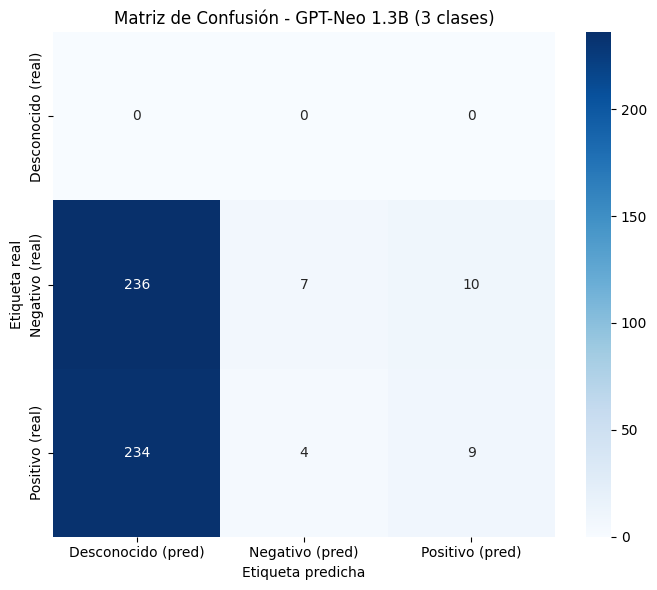

In [63]:
# ---------------------------
# 11. MATRIZ DE CONFUSIÓN 3×3
# ---------------------------
if valid_df.empty:
    print("[ADVERTENCIA] No hay predicciones válidas.")
else:
    # Calculamos la matriz de confusión 3×3 incluyendo la clase -1
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Matriz de confusión
    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Desconocido (pred)", "Negativo (pred)", "Positivo (pred)"],
        yticklabels=["Desconocido (real)", "Negativo (real)", "Positivo (real)"]
    )
    plt.title("Matriz de Confusión - GPT-Neo 1.3B (3 clases)")
    plt.xlabel("Etiqueta predicha")
    plt.ylabel("Etiqueta real")
    plt.tight_layout()
    plt.show()

Veamos ahora algunos ejemplos de reseñas que no fueron clasificadas correctamente.

In [64]:
# ------------------------
# 12. EJEMPLOS DE ERRORES
# -----------------------
if valid_df.empty:
    print("[ADVERTENCIA] No hay predicciones válidas.")
else:
    # Analizamos los errores
    mismatches = valid_df[valid_df["true_label"] != valid_df["pred_label"]]
    if not mismatches.empty:
        print("\nEjemplos de errores de clasificación:")
        for _, row in mismatches.head(3).iterrows():
            print(f"\n📝 Reseña: {row['review'][:300]}...")
            print(f"➡️ Real: {row['sentiment']} | Predicha: {row['pred_label']} | Respuesta: '{row['pred_reply']}'")


Ejemplos de errores de clasificación:

📝 Reseña: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok ...
➡️ Real: positive | Predicha: -1 | Respuesta: 'I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Stein

I really liked this Summerslam due to the look of the arena, the curtains and just th

Controlemos las predicciones que no fueron reconocidas.

In [65]:
# ------------------------------------------
# 13. CONTROL DE PREDICCIONES NO RECONOCIDAS
# ------------------------------------------
not_recognized = df_gptneo[df_gptneo["pred_label"] == -1]
if not_recognized.shape[0] > 0:
    print(f"[INFO] Predicciones no reconocidas: {len(not_recognized)}")
    print("Ejemplos:")
    print(not_recognized[["review", "pred_reply", "sentiment"]].head(5))

[INFO] Predicciones no reconocidas: 470
Ejemplos:
                                              review  \
0  I really liked this Summerslam due to the look...   
1  Not many television shows appeal to quite as m...   
2  The film quickly gets to a major chase scene w...   
3  Jane Austen would definitely approve of this o...   
4  Expectations were somewhat high for me when I ...   

                                          pred_reply sentiment  
0  I really liked this Summerslam due to the look...  positive  
1  Farscape is a science fiction/fantasy show, an...  positive  
2  "The film quickly gets to a major chase scene ...  negative  
3  I think you are right, but I think it is a bit...  positive  
4  The film is a comedy, and the film is a comedy...  negative  


Finalmente, Guardamos los valores en un archivo .CSV.

In [66]:
# -----------------------
# 14. GUARDAR RESULTADOS
# -----------------------
df_gptneo.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"[DONE] Resultados guardados en '{OUTPUT_CSV}'")

[DONE] Resultados guardados en 'saved_models/resultados_gptneo_1.3B.csv'


Recordemos que es importante analizar el uso de memoria en estos modelos autorregresivos, ya que tienen un consumo muy grande de memoria.

In [67]:
# ================================================
# Monitoreo y liberación de memoria GPU en PyTorch
# ================================================

# ----------------------------------------------
# A. Mostrar estado de memoria antes de liberar
# ----------------------------------------------
print("\n=== Estado de memoria ANTES de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria ANTES de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 2186.74 MB
- Memoria reservada (cache): 2730.00 MB



Libramos la memoria eliminando el modelo y el caché.

In [68]:
# -----------------------------------------
# B. Liberar modelo de la memoria de Python
# -----------------------------------------
try:
    del model_gptneo  # borra la variable del modelo
    print("[INFO] Modelo eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'model_tinyllama' no existe o ya fue eliminada.")

try:
    del tokenizer_gptneo  # borra la variable del modelo
    print("[INFO] Tokenizador eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'tokenizer_gptneo' no existe o ya fue eliminada.")

# -----------------------------------
# C. Limpiar caché de GPU de PyTorch
# -----------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # libera la memoria reservada por PyTorch
    torch.cuda.ipc_collect()  # fuerza la recolección de objetos compartidos
    gc.collect()              # limpia memoria de Python
    print("[INFO] Caché de GPU liberada con éxito.")

[INFO] Modelo eliminado de la memoria de Python.
[INFO] Tokenizador eliminado de la memoria de Python.
[INFO] Caché de GPU liberada con éxito.


Controlemos nuevamente cuánto uso de memoria tenemos.

In [69]:
# ---------------------------------------------------------------
# D. Mostrar estado de memoria después de liberar
# ---------------------------------------------------------------
print("\n=== Estado de memoria DESPUÉS de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria DESPUÉS de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 1290.16 MB
- Memoria reservada (cache): 2082.00 MB



Controlemos el uso de memoria usando nvdia-smi.

In [70]:
!nvidia-smi

Tue Oct 21 19:57:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        Off |   00000000:01:00.0 Off |                  N/A |
| 33%   57C    P0            N/A  /   85W |    2411MiB /   4096MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. Modelo BERT

***BERT*** (Bidirectional Encoder Representations from Transformers) es un modelo de lenguaje basado en Transformers desarrollado por ***Google AI Language*** y publicado en el paper “BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding” (Devlin et al., 2018).
Su objetivo fue mejorar la comprensión del lenguaje natural (NLP) aprovechando un entrenamiento ***bidireccional*** sobre grandes corpus de texto, algo que los modelos anteriores no lograban de manera eficiente. Su objetivo fue mejorar la comprensión del lenguaje natural (NLP) aprovechando un entrenamiento bidireccional sobre grandes corpus de texto, algo que los modelos anteriores no lograban de manera eficiente. 

BERT marcó un antes y un después en el campo del NLP, ya que introdujo un nuevo paradigma de pre-entrenamiento y fine-tuning, convirtiéndose en la base de muchos modelos posteriores (RoBERTa, ALBERT, DistilBERT, etc.).

#### Arquitectura General

BERT está construido completamente sobre la arquitectura Transformer Encoder (no utiliza el decodificador). Su estructura básica incluye:
* ***N capas (bloques) Transformer Encoder*** (12 para BERT-base, 24 para BERT-large).
* Cada capa incluye:
    * Un mecanismo de Self-Attention multi-cabeza.
    * Una feed-forward network (dos capas lineales con activación GELU).
    * Normalización por capas y conexiones residuales.
* ***Positional Embeddings***: codifican el orden de las palabras (ya que los Transformers no tienen estructura secuencial intrínseca).
* ***Segment Embeddings***: indican si una palabra pertenece a la oración A o B (útil en tareas de pares de oraciones).

***Ejemplo de configuración:***

| Versión    | Capas | Cabezas de atención | Dimensión oculta | Parámetros |
| ---------- | ----- | ------------------- | ---------------- | ---------- |
| BERT-base  | 12    | 12                  | 768              | ~110M      |
| BERT-large | 24    | 16                  | 1024             | ~340M      |

#### Entrenamiento: Pre-training

BERT fue entrenado en dos tareas principales sobre un corpus enorme (Wikipedia + BookCorpus, >3.3 mil millones de palabras):

* ***a) Masked Language Modeling (MLM)***
    * Se enmascaran aleatoriamente el 15% de las palabras de entrada.
    * El modelo debe predecir las palabras ocultas usando el contexto a izquierda y derecha.
    * Esto entrena a BERT de forma bidireccional, entendiendo simultáneamente el pasado y el futuro del texto.
> Ejemplo:
>
> Entrada: “The [MASK] sat on the mat.” Predicción: “cat”

* ***(b) Next Sentence Prediction (NSP)***
* Se le muestran pares de oraciones (A, B).
* En el 50% de los casos, B es la oración siguiente real de A.
* En el otro 50%, es una oración aleatoria.
* El modelo aprende relaciones semánticas entre oraciones (útil para QA o inferencia textual).

#### Fine-tuning

Después del pre-entrenamiento general, BERT se ajusta para tareas específicas añadiendo una capa final (por ejemplo, una capa softmax).
Este fine-tuning requiere relativamente pocos datos y puede aplicarse a tareas como:
* ***Clasificación de texto*** (sentiment analysis, topic classification)
* ***Reconocimiento de entidades (NER)***
* ***Pregunta-respuesta (QA)***
* ***Inferencia textual (NLI)***
* ***Búsqueda semántica o matching de oraciones***

El proceso es muy eficiente porque la mayoría de los parámetros ya están entrenados para entender lenguaje natural general.

#### Funcionamiento Bidireccional

A diferencia de modelos anteriores como GPT o ELMo, BERT utiliza una atención ***completamente bidireccional***. Esto significa que, para predecir una palabra, tiene acceso tanto al contexto anterior como al posterior en la oración. En cambio:
* GPT es ***unidireccional*** (izquierda → derecha).
* ELMo es ***bidireccional***, pero con dos RNNs independientes, no integradas.

Esta diferencia hace que BERT entienda mejor relaciones semánticas complejas entre palabras dentro de una frase.

####  Capacidades

* ***Comprensión profunda del contexto***: entiende significados ambiguos según el entorno.
* ***Adaptabilidad***: puede especializarse fácilmente a distintas tareas con poco fine-tuning.
* ***Base de muchos modelos modernos***: ha sido el punto de partida de arquitecturas más eficientes como:
    * ***RoBERTa*** (entrenamiento optimizado sin NSP)
    * ***ALBERT*** (reducción de parámetros)
    * ***DistilBERT*** (versión más ligera)
    * ***DeBERTa*** (mejor separación de contexto y posición)

🔹 7. Limitaciones

* ***Costo computacional***:
    * BERT es pesado, especialmente BERT-large (~340M parámetros).
    * Requiere GPUs potentes para entrenamiento o inferencia rápida.
* ***Tamaño de entrada limitado***:
    * Máximo de 512 tokens, lo que complica el procesamiento de textos largos.
* ***No generativo***:
    * BERT no puede generar texto, solo comprender o clasificar.
* ***Contexto estático***:
    * No maneja contexto dinámico de conversación como los modelos autoregresivos (GPT, LLaMA).

####  Comparación con GPT-Neo y TinyLlama

| Característica           | **BERT**                        | **GPT-Neo (1.3B)**                 | **TinyLlama (1.1B)**               |
| ------------------------ | ------------------------------- | ---------------------------------- | ---------------------------------- |
| **Tipo de modelo**       | Encoder (no generativo)         | Decoder autoregresivo              | Decoder autoregresivo optimizado   |
| **Entrenamiento**        | MLM + NSP                       | Autoregresivo (predict next token) | Autoregresivo                      |
| **Direccionalidad**      | Bidireccional                   | Unidireccional                     | Unidireccional                     |
| **Tokens máximos**       | 512                             | 2048                               | 2048+                              |
| **Uso típico**           | Comprensión (NLP clásico)       | Generación y comprensión general   | Generación ligera y eficiente      |
| **Tamaño típico**        | 110M – 340M                     | 1.3B                               | 1.1B                               |
| **Velocidad**            | Media                           | Lenta                              | Rápida (entrenada para eficiencia) |
| **Uso en GPU**           | Eficiente en lotes pequeños     | Requiere buena VRAM                | Muy optimizado para CUDA y CPU     |
| **Ventaja principal**    | Precisión en tareas de análisis | Fluidez generativa                 | Ligereza y velocidad               |
| **Desventaja principal** | No genera texto                 | Pesado y más lento                 | Menor comprensión contextual       |

####  Aplicaciones prácticas

* Análisis de sentimiento (IMDB, Twitter, Amazon reviews)
* Clasificación de temas o intenciones
* Detección de entidades (NER)
* Búsqueda semántica y recuperación de información
* Tareas de comprensión lectora (SQuAD)
* Matching de preguntas y respuestas

####  Variantes y evolución

Después de BERT surgieron mejoras notables:

| Modelo         | Innovación principal                     |
| -------------- | ---------------------------------------- |
| **RoBERTa**    | Eliminó NSP y mejoró preentrenamiento    |
| **ALBERT**     | Parámetros compartidos → menor tamaño    |
| **DistilBERT** | Compresión (más pequeño y rápido)        |
| **SpanBERT**   | Mejor predicción de fragmentos completos |
| **DeBERTa**    | Representaciones de posición mejoradas   |

####  Implementacion del modelo

En lo que sigue, definiremos los hiperparámetros y configuraciones generales.

In [2]:
# ============================================================
# Fine-tuning de BERT para clasificación de sentimiento (IMDB)
# ============================================================
# - Modelo base: bert-base-uncased (se cambiar por otro BERT-compatible)
# - Tarea: clasificar reviews IMDB en positive / negative (2 clases)
# - Framework: PyTorch + Hugging Face Transformers
# ============================================================

# ----------------------------
# 1. CONFIG / HIPERPARÁMETROS
# ----------------------------
# Ruta al CSV del dataset (IMDB Dataset.csv con columnas 'review' y 'sentiment')
DATA_PATH = "imdb_dataset/IMDB Dataset.csv"

# Nombre del modelo preentrenado (BERT base, uncased)
MODEL_NAME = "distilbert-base-uncased"   # 40% más liviano

# Parámetros de entrenamiento
RANDOM_SEED = 42                     # semilla para reproducibilidad
MAX_LEN = 256                        # longitud máxima de tokens por reseña
BATCH_SIZE = 16                       # tamaño de batch (ajusta a la VRAM)
EPOCHS = 20                          # número de épocas (ajusta según recursos)
LR = 2e-5                            # tasa de aprendizaje típica para fine-tuning BERT
WEIGHT_DECAY = 0.01                  # decaimiento de peso para AdamW

# Early stopping
EARLY_STOPPING_PATIENCE = 3          # paciencia en épocas sin mejora (val_loss)

# Carpeta para guardar modelos y tokenizer
OUTPUT_DIR = "bert_imdb_checkpoint"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Controlamos el uso de CUDA.

In [3]:
# ----------------------------
# 2. DISPOSITIVO (GPU si hay)
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Usando dispositivo: {device}")

[INFO] Usando dispositivo: cuda


Luego, determinamos la semilla para poder reproducirlo en Pytorch y numpy.

In [4]:
# ----------------------------------
# 3. SEMILLA (determinismo relativo)
# ----------------------------------
def set_seed(seed: int):
    """Configura semilla para reproducibilidad en PyTorch / numpy / random."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Determinamo la semilla
set_seed(RANDOM_SEED)

Cargamos el Dataset nuevamente, por consistencia.

In [5]:
# ------------------
# 4. CARGAR DATASET
# ------------------
# Validamos que el archivo exista
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"No se encontró el archivo: {DATA_PATH}. Pon el CSV con 'review' y 'sentiment' en la ruta.")

# Leemos el CSV con pandas
df = pd.read_csv(DATA_PATH)

# Aseguramos que existan las columnas necesarias
if "review" not in df.columns or "sentiment" not in df.columns:
    raise ValueError("El CSV debe contener las columnas 'review' y 'sentiment'.")

# Normalizamos las etiquetas a 0/1 (positive -> 1, negative -> 0)
df["sentiment"] = df["sentiment"].str.lower().str.strip()
df = df[df["sentiment"].isin(["positive", "negative"])].copy()  # filtro por seguridad
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})

# Para pruebas rápidas, muestreamos una parte (comenta para usar todo)
df_bert = df.sample(50000, random_state=RANDOM_SEED).reset_index(drop=True)

# Mostramos tamaño y primeras filas para inspección rápida
print(f"[INFO] Dataset cargado: {len(df_bert)} filas.")

[INFO] Dataset cargado: 50000 filas.


Generamos el conjunto de entrenamiento, el conjunto de validación y el conjunto de prueba. 

In [6]:
# ------------------------------
# 5. SPLIT TRAIN / VALID / TEST
# ------------------------------
# Primero separamos train+val y test (80% train_val, 20% test)
train_val_df, test_df = train_test_split(
    df_bert, test_size=0.2, random_state=RANDOM_SEED, stratify=df_bert["label"]
)

# Luego separamos train y validation (de train_val, 90/10 -> resultado approx 72/8/20)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.1, random_state=RANDOM_SEED, stratify=train_val_df["label"]
)

# Imprimimos tamaños
print(f"[INFO] Tamaños: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

[INFO] Tamaños: train=36000, val=4000, test=10000


Aplicamos el Tokenizador

In [7]:
# ----------------------------
# 6. TOKENIZER (Hugging Face)
# ----------------------------
# Cargamos tokenizer del modelo BERT elegido
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)

Luego, definmos una funcion que sea capaz de toquenizar los Datasets

In [8]:
# --------------------------------------------
# 7. DATASET PyTorch con tokenización aplicada
# --------------------------------------------
class IMDBDatasetTorch(Dataset):
    """
    Dataset PyTorch para IMDB.
    - Recibe un dataframe con columnas 'review' y 'label'
    - Tokeniza en __init__ o __getitem__ (aquí tokenizamos en __getitem__ para ahorrar memoria)
    """
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.df = df.reset_index(drop=True)   # guardamos el dataframe interno
        self.tokenizer = tokenizer            # tokenizer Hugging Face
        self.max_len = max_len                # longitud máxima de tokens

    def __len__(self):
        # número de muestras
        return len(self.df)

    def __getitem__(self, idx):
        # obtener fila por índice
        row = self.df.iloc[idx]
        text = str(row["review"])             # texto de la reseña
        label = int(row["label"])             # etiqueta 0/1

        # tokenizamos el texto (truncado/padded en batch por DataLoader collate)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,         # agrega [CLS] y [SEP]
            max_length=self.max_len,         # truncado hasta MAX_LEN
            padding="max_length",            # rellena hasta MAX_LEN (simplifica batching)
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        # sacamos tensores y los devolvemos (aplanamos la primera dimensión)
        item = {
            "input_ids": encoding["input_ids"].squeeze(0),          # tensor long [max_len]
            "attention_mask": encoding["attention_mask"].squeeze(0),# tensor long [max_len]
            "labels": torch.tensor(label, dtype=torch.long)         # etiqueta long (CrossEntropy expects long)
        }
        return item

# Instanciamos datasets de train/val/test
train_dataset = IMDBDatasetTorch(train_df, tokenizer_bert, max_len=MAX_LEN)
val_dataset = IMDBDatasetTorch(val_df, tokenizer_bert, max_len=MAX_LEN)
test_dataset = IMDBDatasetTorch(test_df, tokenizer_bert, max_len=MAX_LEN)

# Imprimimos los archivos obtenidos
print(train_dataset)
print(val_dataset)
print(test_dataset)

Luego, creamos los Dataloaders.

In [9]:
# ---------------
# 8. DATALOADERS
# ---------------
# DataLoader con shuffle para entrenamiento
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Imprimimos los archivos obtenidos
print(train_loader)
print(val_loader)
print(test_loader)

Ya estamos en instancia de generar el modelo de entrenamiento de BERT.

In [10]:
# ------------------------------------
# 9. MODELO (BERT para clasificación)
# -----------------------------------
# Cargamos un modelo BERT con cabeza de clasificación (2 etiquetas)
model_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# Movemos el modelo al dispositivo (GPU o CPU)
model_bert.to(device)

# Imprimimos el modelo
print(model_bert)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Nótese que:

* `from_pretrained(MODEL_NAME)` carga los ***pesos del modelo base*** (bert-base-uncased, por ejemplo).
* `AutoModelForSequenceClassification` agrega encima del encoder BERT una ***capa lineal*** (`classifier`), que transforma las representaciones del [CLS] token en probabilidades de clases.
* `num_labels=2` le indica que queremos ***clasificación binaria*** (por ejemplo, positivo/negativo).

Además, debemos saber que:

* El modelo `bert-base-uncased` fue ***preentrenado*** solo con una tarea de Masked Language Modeling (predecir palabras), ***no*** con clasificación.
* Por eso, sus pesos ***no incluyen una cabeza de clasificación*** (`classifier.weight` y `classifier.bias`).
* Hugging Face crea una ***nueva capa lineal aleatoria*** (por defecto con inicialización normal pequeña).

> Los pesos del encoder BERT vienen preentrenados, pero la cabeza de clasificación se inicializa desde cero y ***debe ser entrenada*** en tu dataset.

Entonces, podés seguir trabajando perfectamente con el modelo:
* Si vamos a entrenarlo (fine-tuning), está todo bien.
* Si queremos usar un modelo ya entrenado para clasificación, entonces tenémos que cargar un checkpoint ya ajustado, por ejemplo:

model = AutoModelForSequenceClassification.from_pretrained(
    "textattack/bert-base-uncased-imdb",
    num_labels=2
)

En resumen:

| Parte del modelo                                               | Fuente de los pesos | Estado                                           |
| -------------------------------------------------------------- | ------------------- | ------------------------------------------------ |
| Encoder BERT                                                   | `bert-base-uncased` |   Cargado desde checkpoint                       |
| Capa de clasificación (`classifier.weight`, `classifier.bias`) | Nueva capa          |   Inicializada aleatoriamente (debe entrenarse)  |

Luego cargamos el optimizador y el scheduler.

In [11]:
# ----------------------------
# 10. OPTIMIZADOR Y SCHEDULER
# ----------------------------
# AdamW con weight decay es el estándar para Transformers
optimizer_bert = AdamW(model_bert.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Número de pasos totales de entrenamiento (para scheduler)
total_steps = len(train_loader) * EPOCHS

# Scheduler lineal con warmup (calentamiento)
warmup_steps = int(0.1 * total_steps)  # 10% warmup típico
scheduler_bert = get_linear_schedule_with_warmup(optimizer_bert, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

Ademas, agregamos el criterio.

In [12]:
# --------------------
# 11. CRITERIO / LOSS
# --------------------
# Para clasificación multi-clase usamos CrossEntropyLoss (built into model outputs as well)
criterion_bert = nn.CrossEntropyLoss() # pérdida para clasificación multiclase

Nótese que:
* `nn` es el ***submódulo de PyTorch*** (`torch.nn`) que contiene las clases para crear ***capas de redes neuronales*** y ***funciones de pérdida***.
* `CrossEntropyLoss` es una ***función de pérdida estándar*** para tareas de ***clasificación multiclase*** (por ejemplo, sentimientos: positivo/negativo, o 3 o más categorías).

***¿Qué hace `CrossEntropyLoss`?***

Esta función mide cuánto ***difieren las predicciones del modelo respecto a las etiquetas reales***. Combina internamente dos operaciones:
1. ***Softmax*** → convierte los logits del modelo (números sin normalizar) en probabilidades (suman 1).
2. ***Negative Log-Likelihood (NLL)*** → penaliza las probabilidades bajas asignadas a la clase correcta.

En fórmula matemática:

$$
Loss=-\frac{1}{N}{\sum_i}log\left(\frac{e^{z_{i,y_{i}}}}{\sum_{j}e^{z_{i,j}}}\right)
$$

donde
* $z_{i,j}=$ logit (salida sin normalizar) del modelo para la muestra $i$ y la clase $j$.
* $y_{i}=$ clase verdadera de la muestra $i$.

***Detalles técnicos***

| Parámetro      | Significado                                                    | Valor por defecto |
| -------------- | -------------------------------------------------------------- | ----------------- |
| `weight`       | Peso para cada clase (para datasets desbalanceados)            | `None`            |
| `reduction`    | Cómo combinar las pérdidas de cada muestra (`'mean'`, `'sum'`) | `'mean'`          |
| `ignore_index` | Etiquetas a ignorar (útil en secuencias o padding)             | `-100`            |

***Resumen***

| Elemento                | Descripción                                               |
| ----------------------- | --------------------------------------------------------- |
| `nn.CrossEntropyLoss()` | Función de pérdida estándar para clasificación.           |
| Combina                 | `log_softmax` + `NLLLoss`                                 |
| Entrada                 | Logits del modelo (no probabilidades).                    |
| Etiquetas               | Enteros (`0 … n_classes-1`).                              |
| Objetivo                | Minimizar la diferencia entre predicción y etiqueta real. |


Antes de comenzar a calcular, debemos definir dos funciones.

In [13]:
# ---------------------------------------------------
# 12. FUNCIONES AUXILIARES (entrenamiento/validación)
# ---------------------------------------------------

# Entrenamiento de una sola época y los parámetros característicos.
def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    """
    Entrena el modelo por una época y devuelve loss promedio y accuracy en ese epoch.
    """
    model.train()                      # ponemos en modo entrenamiento (dropout on)
    running_loss = 0.0                 # acumulador de pérdida
    running_corrects = 0               # contador de aciertos
    total = 0                          # número total de muestras procesadas

    # Iteramos por batches
    for batch in tqdm(dataloader, desc="Train batches", leave=False):
        # Extraemos tensores y los movemos al dispositivo
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Reiniciamos gradientes
        optimizer.zero_grad()

        # Forward: el modelo de transformers retorna un objeto con 'logits' (entre otros)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss                # pérdida ya computada internamente (CrossEntropy)
        logits = outputs.logits            # logits pre-softmax (batch_size, num_labels)

        # Backward: calculamos gradientes
        loss.backward()

        # Actualizamos parámetros
        optimizer.step()
        scheduler.step()

        # Estadísticas de entrenamiento
        running_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=1)
        running_corrects += torch.sum(preds == labels).item()
        total += input_ids.size(0)

    # Calculamos métricas promedio de la época
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

# Evalua el modelo y calcula las mñetricas promedio.
def eval_one_epoch(model, dataloader, device):
    """
    Evalúa el modelo en el dataloader (sin gradientes) y retorna loss promedio, accuracy y arrays de labels/predicciones.
    """
    model.eval()                       # modo evaluación (dropout off)
    running_loss = 0.0                 # pérdida acumulada
    running_corrects = 0               # aciertos acumulados
    total = 0                          # total muestras

    all_preds = []                      # lista para guardar predicciones
    all_labels = []                     # lista para guardar etiquetas verdaderas

    # Desactivamos gradientes para acelerar y ahorrar memoria
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval batches", leave=False):
            # Movemos tensores a device
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            # Estadísticas
            running_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=1)
            running_corrects += torch.sum(preds == labels).item()
            total += input_ids.size(0)

            # Guardamos etiquetas y predicciones (para métricas globales)
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    # Cálculo final
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

En lo que sigue, procederemos a entrenar el modelo.

In [14]:
# ------------------------------------------------------
# 13. LOOP PRINCIPAL DE ENTRENAMIENTO CON EARLY STOPPING
# ------------------------------------------------------
best_val_loss = float("inf")         # mejor val_loss observado
patience_counter = 0                 # contador de épocas sin mejora
train_losses, val_losses = [], []    # listas para graficar
train_accs, val_accs = [], []

# Imprimimos el inicio
print("\n[INFO] Comenzando entrenamiento...")

# Comenzamos con las iteraciones por época
for epoch in range(1, EPOCHS + 1):
    print(f"\n====== Época {epoch}/{EPOCHS} ======")

    # Entrenamiento
    train_loss, train_acc = train_one_epoch(model_bert, train_loader, optimizer_bert, scheduler_bert, device)
    print(f"[TRAIN] loss={train_loss:.4f} acc={train_acc:.4f}")

    # Validación
    val_loss, val_acc, _, _ = eval_one_epoch(model_bert, val_loader, device)
    print(f"[VAL]   loss={val_loss:.4f} acc={val_acc:.4f}")

    # Guardamos métricas para graficar
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Early stopping / guardado del mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Guardamos el state_dict del mejor modelo
        torch.save(model_bert.state_dict(), os.path.join(OUTPUT_DIR, "best_bert_state_dict.pth"))
        # Guardamos el tokenizer (útil para inferencia posterior)
        tokenizer_bert.save_pretrained(OUTPUT_DIR)
        print("[INFO] Mejor modelo guardado (state_dict + tokenizer).")
    else:
        patience_counter += 1
        print(f"[INFO] Sin mejora en validación (patience {patience_counter}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("[INFO] Early stopping activado. Terminando entrenamiento.")
            break


[INFO] Comenzando entrenamiento...

====== Época 1/20 ======


[TRAIN] loss=0.3643 acc=0.8196


[VAL]   loss=0.2729 acc=0.8852
[INFO] Mejor modelo guardado (state_dict + tokenizer).

====== Época 2/20 ======


[TRAIN] loss=0.2146 acc=0.9159


[VAL]   loss=0.2489 acc=0.9010
[INFO] Mejor modelo guardado (state_dict + tokenizer).

====== Época 3/20 ======


...

[VAL]   loss=0.2578 acc=0.9058
[INFO] Sin mejora en validación (patience 1/3)

====== Época 4/20 ======


[TRAIN] loss=0.0740 acc=0.9742


[VAL]   loss=0.3034 acc=0.9055
[INFO] Sin mejora en validación (patience 2/3)

====== Época 5/20 ======


[TRAIN] loss=0.0411 acc=0.9868


[VAL]   loss=0.3676 acc=0.9085
[INFO] Sin mejora en validación (patience 3/3)
[INFO] Early stopping activado. Terminando entrenamiento.


En lo que sigue, veamos las curvas de aprendizaje, tanto las de pérdida como de las métricas para los valores de entrenamiento y validación.

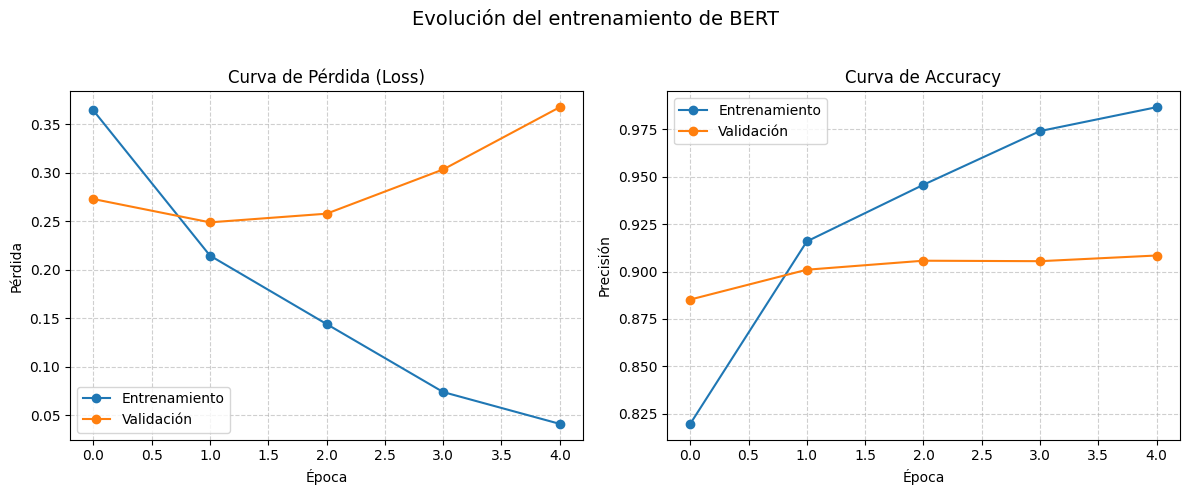

In [15]:
# -----------------------------------------
# 14. CURVAS DE ENTRENAMIENTO Y VALIDACIÓN
# -----------------------------------------
plt.figure(figsize=(12, 5))

# ---- Curva de pérdida (Loss) ----
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Entrenamiento", marker='o')
plt.plot(val_losses, label="Validación", marker='o')
plt.title("Curva de Pérdida (Loss)")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# ---- Curva de accuracy ----
plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Entrenamiento", marker='o')
plt.plot(val_accs, label="Validación", marker='o')
plt.title("Curva de Accuracy")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Evolución del entrenamiento de BERT", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

Ya hemos entrenado el modelo, por lo que debemos calcular las métricas.

In [16]:
# ------------------------------------------------------
# 15. EVALUACIÓN FINAL EN TEST SET (con el mejor modelo)
# ------------------------------------------------------
# Cargamos el mejor modelo guardado en disco (reconstrucción y carga de pesos)
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
best_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_bert_state_dict.pth"), map_location=device))
best_model.to(device)
best_model.eval()

# Evaluamos en test set
test_loss, test_acc, y_true, y_pred = eval_one_epoch(best_model, test_loader, device)

# Imprimimos métricas básicas
print("\n[TEST] Resultado final sobre set de prueba:")
print(f"Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

# Métricas detalladas con sklearn
print("\nReporte de clasificación (sklearn):")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"], digits=4, zero_division=0))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
                                                                                                         


[TEST] Resultado final sobre set de prueba:
Loss: 0.2183, Accuracy: 0.9140

Reporte de clasificación (sklearn):
              precision    recall  f1-score   support

    negative     0.9438    0.8804    0.9110      5000
    positive     0.8879    0.9476    0.9168      5000

    accuracy                         0.9140     10000
   macro avg     0.9159    0.9140    0.9139     10000
weighted avg     0.9159    0.9140    0.9139     10000



Además, graficamos la matriz de confusión.

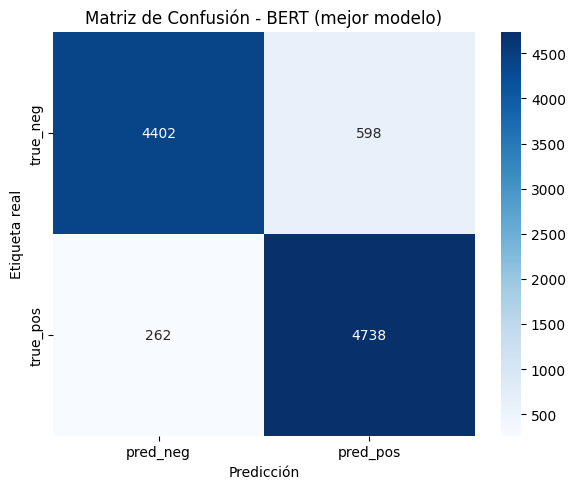

In [17]:
# Matriz de confusión y plotting
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred_neg", "pred_pos"],
            yticklabels=["true_neg", "true_pos"])
plt.title("Matriz de Confusión - BERT (mejor modelo)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

Por último, guardamos el mejor modelo entrenado.

In [18]:
# -------------------------------------
# 16. GUARDAR RESULTADOS Y MODELO FINAL
# -------------------------------------
# Guardamos reporte y métricas en un CSV simple
results_df = pd.DataFrame({
    "text": test_df["review"].values,
    "true_label": y_true,
    "pred_label": y_pred
})
results_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False, encoding="utf-8")
print(f"[INFO] Predicciones de test guardadas en {os.path.join(OUTPUT_DIR, 'test_predictions.csv')}")

# Guardamos el modelo completo (opcional)
best_model.save_pretrained(os.path.join(OUTPUT_DIR, "best_model_full"))
print(f"[INFO] Modelo completo guardado en {os.path.join(OUTPUT_DIR, 'best_model_full')}")

# Finalizamos
print("[DONE] Fine-tuning y evaluación de BERT completados.")

[INFO] Predicciones de test guardadas en bert_imdb_checkpoint/test_predictions.csv
[INFO] Modelo completo guardado en bert_imdb_checkpoint/best_model_full
[DONE] Fine-tuning y evaluación de BERT completados.


Nuevamente y por última vez, es importante analizar el uso de memoria, ya que todos estos modelos tienen un consumo muy grande de memoria.

In [22]:
# ================================================
# Monitoreo y liberación de memoria GPU en PyTorch
# ================================================

# ----------------------------------------------
# A. Mostrar estado de memoria antes de liberar
# ----------------------------------------------
print("\n=== Estado de memoria ANTES de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria ANTES de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 1071.35 MB
- Memoria reservada (cache): 1162.00 MB



Eliminamos los modelos y limpiamos la memoria.

In [23]:
# ----------------------------
# B. Liberar memoria de Python
# ----------------------------
try:
    del model_bert  # borra la variable del modelo
    print("[INFO] Modelo eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'model_bert' no existe o ya fue eliminada.")

try:
    del tokenizer_bert  # borra el optimizador
    print("[INFO] Tokenizador eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'tokenizer_bert' no existe o ya fue eliminada.")

try:
    del best_model  # borra la variable del mejor modelo
    print("[INFO] Mejor modelo eliminado de la memoria de Python.")
except NameError:
    print("[ADVERTENCIA] La variable 'best_model' no existe o ya fue eliminada.")

# -----------------------------------
# C. Limpiar caché de GPU de PyTorch
# -----------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # libera la memoria reservada por PyTorch
    torch.cuda.ipc_collect()  # fuerza la recolección de objetos compartidos
    gc.collect()              # limpia memoria de Python
    print("[INFO] Caché de GPU liberada con éxito.")

[ADVERTENCIA] La variable 'model_bert' no existe o ya fue eliminada.
[ADVERTENCIA] La variable 'tokenizer_bert' no existe o ya fue eliminada.
[ADVERTENCIA] La variable 'best_model' no existe o ya fue eliminada.
[INFO] Caché de GPU liberada con éxito.


Verificamos la memoria

In [24]:
# ---------------------------------------------------------------
# D. Mostrar estado de memoria después de liberar
# ---------------------------------------------------------------
print("\n=== Estado de memoria DESPUÉS de liberar ===")
mostrar_memoria_gpu()


=== Estado de memoria DESPUÉS de liberar ===
Nombre de la GPU: NVIDIA GeForce GTX 1650
💾 Memoria total GPU: 3714.69 MB
- Memoria usada por tensores: 1071.35 MB
- Memoria reservada (cache): 1162.00 MB



#### Resumen Final

BERT introdujo el concepto de bidirectional contextual embeddings y cambió la forma en que los modelos entienden el lenguaje. Su capacidad para ***capturar contexto en ambas direcciones*** lo hizo extremadamente poderoso para tareas de comprensión, aunque no es adecuado para generación de texto libre. Por ello, en aplicaciones modernas se lo usa como encoder dentro de sistemas más grandes, o se lo combina con modelos autoregresivos (como GPT o TinyLlama) para tareas mixtas.

## 6. Conclusiones

El análisis comparativo entre el modelo BiLSTM con capas de atención, los modelos autorregresivos (TinyLLaMA y GPT-Neo) y el modelo BERT evidencia diferencias sustanciales en arquitectura, eficiencia y capacidad de generalización para tareas de comprensión semántica como la clasificación de sentimientos en texto.

#### BiLSTM + Atención

El modelo Bidirectional LSTM (BiLSTM) con mecanismos de atención constituye una arquitectura clásica del procesamiento secuencial.
Su fortaleza radica en la modelización contextual bidireccional y en la focalización adaptativa que ofrece la atención, lo cual mejora la interpretación de palabras clave con alta carga emocional.
En datasets moderados como IMDB, logra un buen equilibrio entre interpretabilidad y precisión, con métricas de F1-score entre 0.85 y 0.90 según el preprocesamiento y embeddings (por ejemplo, GloVe o Word2Vec).
Sin embargo, al ser un modelo entrenado desde cero o sobre embeddings fijos, presenta limitaciones para capturar dependencias semánticas de largo alcance o matices sutiles del lenguaje.

#### TinyLLaMA (modelo autorregresivo pequeño)

TinyLLaMA es un modelo autoregresivo liviano, optimizado para entornos con recursos limitados.
Basado en la arquitectura Transformer, genera texto token por token, aprendiendo las distribuciones condicionales del lenguaje.
En tareas de clasificación mediante prompting, demuestra capacidad de razonamiento contextual, pero su rendimiento puede degradarse si el prompt no es explícito o si la generación se desvía de la instrucción ("Answer only with Positive or Negative").
Su principal ventaja es la eficiencia computacional y la posibilidad de inferencia en hardware modesto, aunque sacrifica precisión frente a modelos mayores.
En tareas de sentiment analysis, suele alcanzar F1-scores cercanos a 0.75–0.80, dependiendo del tamaño de muestra y claridad del prompt.

#### GPT-Neo (EleutherAI 1.3B)

GPT-Neo replica la filosofía de GPT-3, pero con un tamaño manejable (1.3B parámetros) y de acceso abierto.
Su desempeño en clasificación de sentimientos mediante zero-shot prompting es notable, mostrando robusto entendimiento semántico sin necesidad de reentrenamiento.
Gracias a su escala y riqueza contextual, produce inferencias coherentes y menos propensas a error frente a TinyLLaMA, aunque con mayor costo computacional (RAM y VRAM).
En práctica, GPT-Neo logra F1-scores entre 0.85 y 0.90, comparables a BiLSTM + Atención, pero con una capacidad de generalización superior ante ejemplos ambiguos o fuera de distribución.

#### BERT (Bidirectional Encoder Representations from Transformers)

BERT representa el paradigma bidireccional no autoregresivo: en lugar de generar texto, estima representaciones contextuales completas de una oración.
Esto lo convierte en el estándar de referencia para tareas de clasificación textual supervisada.
Fine-tuneado sobre datasets como IMDB, BERT supera consistentemente a modelos clásicos y autoregresivos en tareas discriminativas, alcanzando F1-scores superiores al 0.92–0.94. Su entrenamiento bidireccional permite una comprensión más rica de las relaciones sintácticas y semánticas, aunque su inferencia es más pesada que la de modelos LSTM, y su fine-tuning requiere GPU.

#### Comparación General

| Modelo                | Tipo                                | Entrenamiento              | Enfoque        | Interpretabilidad | Precisión esperada (IMDB) | Recursos requeridos |
| :-------------------- | :---------------------------------- | :------------------------- | :------------- | :---------------- | :-----------------------: | :-----------------: |
| **BiLSTM + Atención** | Secuencial (RNN + atención)         | Supervisado                | Discriminativo | Alta              |         0.85–0.90         |      Bajo–Medio     |
| **TinyLLaMA**         | Autoregresivo (Transformer pequeño) | Preentrenado (*zero-shot*) | Generativo     | Media             |         0.75–0.80         |         Bajo        |
| **GPT-Neo 1.3B**      | Autoregresivo (Transformer grande)  | Preentrenado (*zero-shot*) | Generativo     | Media–Alta        |         0.85–0.90         |         Alto        |
| **BERT (base)**       | Bidireccional (Transformer encoder) | Fine-tuned                 | Discriminativo | Media             |         0.92–0.94         |      Medio–Alto     |

#### Síntesis final

En síntesis, mientras que los modelos autoregresivos como TinyLLaMA y GPT-Neo exhiben una sorprendente capacidad zero-shot, su naturaleza generativa los hace más sensibles al diseño del prompt y menos eficientes en tareas puramente discriminativas.
Por el contrario, BERT, gracias a su entrenamiento bidireccional y enfoque supervisado, continúa siendo el modelo de referencia para clasificación de sentimientos de alta precisión.
El modelo BiLSTM + Atención, aunque conceptualmente más simple, sigue siendo competitivo, especialmente cuando se dispone de recursos limitados o se requiere mayor interpretabilidad del proceso de decisión.

En conjunto, la comparación muestra una transición clara:

> desde arquitecturas recurrentes interpretables hacia modelos transformadores preentrenados de amplio contexto, donde el prompt engineering y la cuantización eficiente emergen como herramientas clave para balancear ***precisión, costo y generalización***.